# NB04 — Wildfire Detection: Daily + Hourly Pipeline

**Goal:** Detect wildfire events (binary classification) on an **imbalanced dataset** (~8-9 % positive class).  
**Priority:** **Maximise recall** — for the Ministry of Ecology, missing a real fire is far worse than a false alarm.  
**Precision target:** ≥ 0.30 (raised from 0.10 to reduce false alarms while keeping recall high).

## Part A — Daily Detection (30-day horizon)
**Models:** XGBoost · CatBoost · LightGBM · RandomForest · ExtraTrees · HistGBC · BalancedRF · **MLP Neural Network** + Optuna tuning (100 trials) + Soft-Voting · Stacking · **Role-Blended Ensemble**  
**Input:** `data/processed/engineered_daily.parquet`  
**Output:** `models/wildfire/best_fire_model.joblib`

## Part B — Hourly Detection (168-hour horizon)
**Models:** XGBoost · CatBoost (baselines + Optuna-tuned) with daytime label masking  
**Input:** `data/processed/engineered_hourly.parquet`  
**Output:** `models/wildfire/best_fire_model_hourly.joblib`

## Ensemble Strategy
| Ensemble | Method | Purpose |
|----------|--------|---------|
| **SoftVoting_Top3** | Average top-3 probabilities | Smooth predictions |
| **Stacking_Top3** | LogReg meta-learner on OOF | Learn optimal combination |
| **RoleBlend_All** | Recall-weighted blend of ALL models | Every model contributes its strength |

## Anti-Overfitting Safeguards
| Measure | Implementation |
|---------|---------------|
| **3-way temporal split** | train (< 2024), val (2024), test (≥ 2025) |
| **Early stopping** | on **validation set** — test is never seen during training |
| **Feature pruning** | drop near-zero-variance + highly correlated (r > 0.95) |
| **Recall-first threshold** | tuned on validation set; fallback cascade if no threshold meets gates |
| **Overfitting monitor** | train-vs-val metric gap printed for every model |

In [1]:
# ─── Cell 1: Imports & paths ─────────────────────────────────────────────
import subprocess, sys, os, warnings, json, time, copy
from pathlib import Path

for _p in ["xgboost","catboost","lightgbm","optuna",
           "scikit-learn","imbalanced-learn","shap","joblib","tqdm"]:
    try: __import__(_p.replace("-","_"))
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", _p])

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix,
    f1_score, recall_score, precision_score, accuracy_score,
    precision_recall_curve, average_precision_score, roc_auc_score,
    precision_recall_fscore_support)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
    HistGradientBoostingClassifier, VotingClassifier, StackingClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.isotonic import IsotonicRegression
from joblib import dump as jl_dump
import xgboost as xgb, catboost as cb, lightgbm as lgb
import optuna
from tqdm.auto import tqdm

try:
    from imblearn.ensemble import BalancedRandomForestClassifier
except ImportError:
    BalancedRandomForestClassifier = None

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style="whitegrid")

# ── Paths (src.config) ───────────────────────────────────────────────────
sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()))
from src.config import (ROOT, PROCESSED, MODELS_F, FIGURES, METRICS,
                         TARGET_COL, DROP_COLS, RANDOM_SEED,
                         ENG_DAILY, MASTER_DAILY, ENG_HOURLY)
from src.evaluation import fire_metrics, find_optimal_threshold, build_fire_leaderboard
from src.visualization import (plot_confusion_matrix, plot_pr_curves,
                                plot_feature_importance, plot_leaderboard)

SEED = RANDOM_SEED
np.random.seed(SEED)

# ── Hard metric gates — recall-first, precision raised to 0.30 ──────────
MIN_PRECISION = 0.30   # raised from 0.10 → 0.30 to reduce false alarms
MIN_RECALL    = 0.70   # MUST catch fires
MIN_F1        = 0.20   # floor for sanity

print(f"Root : {ROOT}")
print(f"Targets : Precision≥{MIN_PRECISION}  Recall≥{MIN_RECALL}  F1≥{MIN_F1}")
print(f"Priority: RECALL-FIRST — missing a fire is worse than a false alarm")

Root : /home/manheim666/Desktop/My_WildFire
Targets : Precision≥0.3  Recall≥0.7  F1≥0.2
Priority: RECALL-FIRST — missing a fire is worse than a false alarm


## §1 — Load Data & 3-Way Temporal Split

Split strictly by time to prevent any look-ahead leakage:
- **Train:** all dates before 2024-01-01
- **Validation:** 2024-01-01 → 2024-12-31 (for early stopping, threshold tuning, calibration)
- **Test:** 2025-01-01 onward (touched **only** at final evaluation)

In [2]:
# ─── §1: Load & split ────────────────────────────────────────────────────
data_path = ENG_DAILY if ENG_DAILY.exists() else MASTER_DAILY
df = pd.read_parquet(data_path)
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["City", "Date"]).reset_index(drop=True)
print(f"Loaded: {df.shape}  from {data_path.name}")
print(f"Fire rate: {df[TARGET_COL].mean()*100:.2f}%  ({df[TARGET_COL].sum()} fires / {len(df)} rows)")

# ── Temporal split ────────────────────────────────────────────────────────
VAL_DATE  = "2024-01-01"
TEST_DATE = "2025-01-01"

train_df = df[df["Date"] <  VAL_DATE].copy()
val_df   = df[(df["Date"] >= VAL_DATE) & (df["Date"] < TEST_DATE)].copy()
test_df  = df[df["Date"] >= TEST_DATE].copy()

# ── Feature columns ──────────────────────────────────────────────────────
exclude = set(DROP_COLS) | {"City", "Date", "Timestamp", "Year"}
feature_cols = [c for c in df.columns
                if c not in exclude
                and c != TARGET_COL
                and df[c].dtype in ("float64","float32","int64","int32","uint8")]

X_train, y_train = train_df[feature_cols].fillna(0), train_df[TARGET_COL]
X_val,   y_val   = val_df[feature_cols].fillna(0),   val_df[TARGET_COL]
X_test,  y_test  = test_df[feature_cols].fillna(0),  test_df[TARGET_COL]

IMBALANCE_RATIO = round((y_train == 0).sum() / max((y_train == 1).sum(), 1), 1)

print(f"\n{'Split':10s} {'Rows':>7s} {'Fire%':>7s} {'Fires':>6s}")
print("-" * 40)
for name, y in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    print(f"{name:10s} {len(y):7,d} {y.mean()*100:6.2f}% {int(y.sum()):6d}")
print(f"\nImbalance ratio (neg/pos): {IMBALANCE_RATIO}")
print(f"Features: {len(feature_cols)}")

Loaded: (83568, 269)  from engineered_daily.parquet
Fire rate: 8.07%  (6740 fires / 83568 rows)

Split         Rows   Fire%  Fires
----------------------------------------
Train       69,840   8.32%   5813
Val          5,856   6.11%    358
Test         7,872   7.23%    569

Imbalance ratio (neg/pos): 11.0
Features: 259


## §2 — Feature Pruning

Remove noise to reduce overfitting:
1. **Near-zero variance** (std < 0.001) — constant columns carry no signal
2. **High correlation** (|r| > 0.95) — keep the one more correlated with fire
3. Print how many survive

In [3]:
# ─── §2: Feature pruning ─────────────────────────────────────────────────
n_before = len(feature_cols)

# 2a. Near-zero variance
stds = X_train.std()
low_var = stds[stds < 0.001].index.tolist()
print(f"Near-zero variance columns removed: {len(low_var)}")

# 2b. High correlation
keep_cols = [c for c in feature_cols if c not in low_var]
corr = X_train[keep_cols].corr().abs()
fire_corr = X_train[keep_cols].corrwith(y_train).abs()

to_drop = set()
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        if corr.iloc[i, j] > 0.95:
            ci, cj = corr.columns[i], corr.columns[j]
            if ci in to_drop or cj in to_drop:
                continue
            # Drop the one LESS correlated with fire
            drop = cj if fire_corr.get(ci, 0) >= fire_corr.get(cj, 0) else ci
            to_drop.add(drop)

print(f"Highly correlated columns removed: {len(to_drop)}")

feature_cols = [c for c in keep_cols if c not in to_drop]
X_train = X_train[feature_cols]
X_val   = X_val[feature_cols]
X_test  = X_test[feature_cols]

print(f"\nFeatures: {n_before} → {len(feature_cols)} (removed {n_before - len(feature_cols)})")

# Quick sanity check: top-10 fire-correlated features
fc = X_train.corrwith(y_train).sort_values(key=abs, ascending=False)
print("\nTop 10 features by |correlation| with Fire_Occurred:")
for feat, val in fc.head(10).items():
    print(f"  {feat:45s} {val:+.4f}")

Near-zero variance columns removed: 0


Highly correlated columns removed: 75

Features: 259 → 184 (removed 75)

Top 10 features by |correlation| with Fire_Occurred:
  fire_count_14d                                +0.3705
  fire_count_7d                                 +0.3644
  fire_count_30d                                +0.3527
  city_month_fire_rate                          +0.3182
  fire_count_90d                                +0.2486
  Soil_Moisture_max                             -0.2124
  temp_x_wind                                   +0.2050
  FFMC_proxy                                    +0.2012
  FWI_proxy                                     +0.1994
  Soil_Temp_C_max                               +0.1974


## §3 — Cost-Sensitive Baselines (9 Models)

Train **all available classifiers** with built-in class weighting or balanced variants, plus an **MLP Neural Network**. Each model gets a recall-optimized threshold from the validation set.

In [4]:
# ─── §3: Train 9 cost-sensitive baselines (including MLP) ─────────────────
results = {}

MODELS = {
    "XGBoost": xgb.XGBClassifier(
        n_estimators=500, max_depth=7, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=IMBALANCE_RATIO,
        reg_alpha=0.5, reg_lambda=1.0, min_child_weight=5,
        eval_metric="aucpr", early_stopping_rounds=30,
        random_state=SEED, use_label_encoder=False, n_jobs=-1),
    "CatBoost": cb.CatBoostClassifier(
        iterations=500, depth=7, learning_rate=0.05,
        auto_class_weights="Balanced", l2_leaf_reg=3.0,
        random_seed=SEED, verbose=0),
    "LightGBM": lgb.LGBMClassifier(
        n_estimators=500, max_depth=7, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=IMBALANCE_RATIO,
        reg_alpha=0.5, reg_lambda=1.0, min_child_weight=5,
        random_state=SEED, n_jobs=-1, verbose=-1),
    "RandomForest": RandomForestClassifier(
        n_estimators=500, max_depth=20, min_samples_leaf=5,
        class_weight="balanced", random_state=SEED, n_jobs=-1),
    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=500, max_depth=20, min_samples_leaf=5,
        class_weight="balanced", random_state=SEED, n_jobs=-1),
    "HistGBC": HistGradientBoostingClassifier(
        max_iter=500, max_depth=7, learning_rate=0.05,
        class_weight="balanced", random_state=SEED),
    "MLP_Neural": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", MLPClassifier(
            hidden_layer_sizes=(256, 128, 64),
            activation="relu", solver="adam", alpha=1e-3,
            batch_size=512, learning_rate="adaptive",
            learning_rate_init=1e-3, max_iter=300,
            early_stopping=True, validation_fraction=0.15,
            n_iter_no_change=15, random_state=SEED)),
    ]),
}

if BalancedRandomForestClassifier is not None:
    MODELS["BalancedRF"] = BalancedRandomForestClassifier(
        n_estimators=500, max_depth=20, min_samples_leaf=5,
        random_state=SEED, n_jobs=-1)

print(f"Training {len(MODELS)} baseline models …\n")
print(f"{'Model':15s} {'Thr':>5s} {'Recall':>7s} {'Prec':>7s} {'F1':>7s} "
      f"{'PR-AUC':>7s} {'Tr-F1':>6s} {'Gap':>6s} {'Time':>6s} {'Pass?':>6s}")
print("-" * 90)

for name, model in MODELS.items():
    t0 = time.time()
    try:
        if "XGB" in name and "xgb" in str(type(model)):
            model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
        elif "LightGBM" in name:
            model.fit(X_train, y_train,
                      eval_set=[(X_val, y_val)],
                      callbacks=[lgb.early_stopping(30, verbose=False),
                                 lgb.log_evaluation(period=0)])
        else:
            model.fit(X_train, y_train)

        y_prob_val  = model.predict_proba(X_val)[:, 1]
        y_prob_test = model.predict_proba(X_test)[:, 1]
        y_prob_train = model.predict_proba(X_train)[:, 1]

        best_thresh = find_optimal_threshold(
            y_val, y_prob_val,
            min_precision=MIN_PRECISION, min_recall=MIN_RECALL)

        y_pred_test  = (y_prob_test >= best_thresh).astype(int)
        y_pred_train = (y_prob_train >= best_thresh).astype(int)

        m = fire_metrics(y_test, y_pred_test, y_prob_test)
        train_f1 = f1_score(y_train, y_pred_train, zero_division=0)
        gap = train_f1 - m["f1"]

        results[name] = {
            "model": model, "y_true": y_test, "y_pred": y_pred_test,
            "y_prob": y_prob_test, "threshold": best_thresh,
            "imbalance_strategy": "class_weight",
            "train_time": time.time() - t0,
            "train_f1": train_f1, "overfit_gap": gap,
        }

        passes = (m["precision"] >= MIN_PRECISION and
                  m["recall"] >= MIN_RECALL and
                  m["f1"] >= MIN_F1)
        flag = "  ✓" if passes else "  ✗"
        print(f"{name:15s} {best_thresh:5.2f} {m['recall']:7.4f} {m['precision']:7.4f} "
              f"{m['f1']:7.4f} {m.get('pr_auc',0):7.4f} {train_f1:6.3f} "
              f"{gap:+6.3f} {time.time()-t0:5.1f}s{flag}")

    except Exception as e:
        print(f"{name:15s} FAILED: {e}")

print(f"\nBaseline models trained: {len(results)}")

Training 8 baseline models …

Model             Thr  Recall    Prec      F1  PR-AUC  Tr-F1    Gap   Time  Pass?
------------------------------------------------------------------------------------------


XGBoost          0.51  0.7170  0.2965  0.4195  0.3889  0.455 +0.035   6.6s  ✗


CatBoost         0.41  0.7540  0.2881  0.4169  0.4127  0.473 +0.056  13.9s  ✗


LightGBM         0.15  0.4780  0.3726  0.4188  0.3491  0.436 +0.017   5.2s  ✗


RandomForest     0.22  0.7469  0.2837  0.4112  0.3769  0.573 +0.162  49.2s  ✗


ExtraTrees       0.34  0.7118  0.2834  0.4054  0.3766  0.573 +0.168  12.7s  ✗


HistGBC          0.49  0.7786  0.2878  0.4203  0.4049  0.429 +0.008   5.8s  ✗


MLP_Neural       0.10  0.7434  0.2720  0.3983  0.3846  0.391 -0.007  23.2s  ✗


BalancedRF       0.47  0.7434  0.2841  0.4111  0.3842  0.520 +0.109  16.4s  ✗

Baseline models trained: 8


## §4 — Optuna Hyperparameter Tuning (100 trials) + Ensemble Models

Tune the **top-3** gradient boosters with **100 trials** each. Objective: **0.6×Recall + 0.4×F1** (recall-first).  
Then build **Soft-Voting**, **Stacking**, and **Role-Blended** ensembles from all trained models.

### Ensemble Strategy
- **SoftVoting_Top3**: Simple average of top-3 model probabilities
- **Stacking_Top3**: LogReg meta-learner trained on OOF base model probabilities  
- **RoleBlend_All**: Every model contributes based on its strength — recall specialists get 2× weight, precision specialists 1×, balanced 1.5×

In [5]:
# ─── §4: Optuna tuning (100 trials) + Ensembles ─────────────────────────
# MANHEIM_RETUNE=1  → force Optuna tuning even if saved model exists
# MANHEIM_SKIP_SHAP=1 → skip SHAP (faster prediction runs)
import os as _os
_RETUNE = _os.environ.get("MANHEIM_RETUNE", "0") == "1"
_SKIP_SHAP = _os.environ.get("MANHEIM_SKIP_SHAP", "0") == "1"
N_TRIALS = int(_os.environ.get("MANHEIM_OPTUNA_TRIALS", "100"))
print(f"Optuna: N_TRIALS={N_TRIALS}  RETUNE={_RETUNE}  SKIP_SHAP={_SKIP_SHAP}")

def _xgb_objective(trial, Xtr, ytr, Xv, yv, ir):
    p = {
        "n_estimators":     trial.suggest_int("n_estimators", 200, 800),
        "max_depth":        trial.suggest_int("max_depth", 4, 10),
        "learning_rate":    trial.suggest_float("lr", 0.01, 0.15, log=True),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample", 0.4, 1.0),
        "min_child_weight": trial.suggest_int("mcw", 1, 20),
        "gamma":            trial.suggest_float("gamma", 0.0, 3.0),
        "reg_alpha":        trial.suggest_float("alpha", 1e-6, 5.0, log=True),
        "reg_lambda":       trial.suggest_float("lambda", 1e-6, 5.0, log=True),
        "scale_pos_weight": trial.suggest_float("spw", ir*0.5, ir*2.0),
    }
    clf = xgb.XGBClassifier(**p, eval_metric="aucpr",
        early_stopping_rounds=20, random_state=SEED,
        use_label_encoder=False, n_jobs=-1)
    clf.fit(Xtr, ytr, eval_set=[(Xv, yv)], verbose=False)
    yp = clf.predict_proba(Xv)[:,1]
    thr = find_optimal_threshold(yv, yp, min_precision=MIN_PRECISION, min_recall=MIN_RECALL)
    yd = (yp >= thr).astype(int)
    rec = recall_score(yv, yd, zero_division=0)
    f1v = f1_score(yv, yd, zero_division=0)
    return 0.6 * rec + 0.4 * f1v

def _cb_objective(trial, Xtr, ytr, Xv, yv, ir):
    p = {
        "iterations":       trial.suggest_int("iterations", 200, 800),
        "depth":            trial.suggest_int("depth", 4, 10),
        "learning_rate":    trial.suggest_float("lr", 0.01, 0.15, log=True),
        "l2_leaf_reg":      trial.suggest_float("l2", 0.1, 10.0, log=True),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
    }
    clf = cb.CatBoostClassifier(**p, auto_class_weights="Balanced",
                                random_seed=SEED, verbose=0)
    clf.fit(Xtr, ytr)
    yp = clf.predict_proba(Xv)[:,1]
    thr = find_optimal_threshold(yv, yp, min_precision=MIN_PRECISION, min_recall=MIN_RECALL)
    yd = (yp >= thr).astype(int)
    rec = recall_score(yv, yd, zero_division=0)
    f1v = f1_score(yv, yd, zero_division=0)
    return 0.6 * rec + 0.4 * f1v

def _lgb_objective(trial, Xtr, ytr, Xv, yv, ir):
    p = {
        "n_estimators":     trial.suggest_int("n_estimators", 200, 800),
        "max_depth":        trial.suggest_int("max_depth", 4, 10),
        "learning_rate":    trial.suggest_float("lr", 0.01, 0.15, log=True),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample", 0.4, 1.0),
        "min_child_weight": trial.suggest_int("mcw", 1, 20),
        "reg_alpha":        trial.suggest_float("alpha", 1e-6, 5.0, log=True),
        "reg_lambda":       trial.suggest_float("lambda", 1e-6, 5.0, log=True),
        "scale_pos_weight": trial.suggest_float("spw", ir*0.5, ir*2.0),
    }
    clf = lgb.LGBMClassifier(**p, random_state=SEED, n_jobs=-1, verbose=-1)
    clf.fit(Xtr, ytr, eval_set=[(Xv, yv)],
            callbacks=[lgb.early_stopping(20, verbose=False),
                       lgb.log_evaluation(period=0)])
    yp = clf.predict_proba(Xv)[:,1]
    thr = find_optimal_threshold(yv, yp, min_precision=MIN_PRECISION, min_recall=MIN_RECALL)
    yd = (yp >= thr).astype(int)
    rec = recall_score(yv, yd, zero_division=0)
    f1v = f1_score(yv, yd, zero_division=0)
    return 0.6 * rec + 0.4 * f1v

# ── Run Optuna for top-3 gradient boosters ───────────────────────────────
optuna_configs = [
    ("XGBoost",  _xgb_objective),
    ("CatBoost", _cb_objective),
    ("LightGBM", _lgb_objective),
]

for base_name, obj_fn_factory in optuna_configs:
    print(f"\n{'='*60}\n  OPTUNA — {base_name} ({N_TRIALS} trials)\n{'='*60}")
    obj_fn = lambda trial: obj_fn_factory(trial, X_train, y_train, X_val, y_val, IMBALANCE_RATIO)
    study = optuna.create_study(direction="maximize", study_name=f"fire_{base_name}")
    study.optimize(obj_fn, n_trials=N_TRIALS, show_progress_bar=True)

    bp = study.best_trial.params
    print(f"  Best val score: {study.best_trial.value:.4f}")

    tag = f"{base_name}_Optuna"
    if base_name == "XGBoost":
        tuned = xgb.XGBClassifier(
            n_estimators=bp["n_estimators"], max_depth=bp["max_depth"],
            learning_rate=bp["lr"], subsample=bp["subsample"],
            colsample_bytree=bp["colsample"], min_child_weight=bp["mcw"],
            gamma=bp["gamma"], reg_alpha=bp["alpha"], reg_lambda=bp["lambda"],
            scale_pos_weight=bp["spw"],
            eval_metric="aucpr", early_stopping_rounds=30,
            random_state=SEED, use_label_encoder=False, n_jobs=-1)
        tuned.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    elif base_name == "CatBoost":
        tuned = cb.CatBoostClassifier(
            iterations=bp["iterations"], depth=bp["depth"],
            learning_rate=bp["lr"], l2_leaf_reg=bp["l2"],
            subsample=bp.get("subsample", 0.8),
            auto_class_weights="Balanced",
            random_seed=SEED, verbose=0)
        tuned.fit(X_train, y_train)
    else:
        tuned = lgb.LGBMClassifier(
            n_estimators=bp["n_estimators"], max_depth=bp["max_depth"],
            learning_rate=bp["lr"], subsample=bp["subsample"],
            colsample_bytree=bp["colsample"], min_child_weight=bp["mcw"],
            reg_alpha=bp["alpha"], reg_lambda=bp["lambda"],
            scale_pos_weight=bp["spw"],
            random_state=SEED, n_jobs=-1, verbose=-1)
        tuned.fit(X_train, y_train, eval_set=[(X_val, y_val)],
                  callbacks=[lgb.early_stopping(30, verbose=False),
                             lgb.log_evaluation(period=0)])

    yp_v  = tuned.predict_proba(X_val)[:,1]
    yp_t  = tuned.predict_proba(X_test)[:,1]
    yp_tr = tuned.predict_proba(X_train)[:,1]
    thr = find_optimal_threshold(y_val, yp_v, min_precision=MIN_PRECISION, min_recall=MIN_RECALL)
    yd_t = (yp_t >= thr).astype(int)
    train_f1 = f1_score(y_train, (yp_tr >= thr).astype(int), zero_division=0)
    m = fire_metrics(y_test, yd_t, yp_t)

    results[tag] = {
        "model": tuned, "y_true": y_test, "y_pred": yd_t,
        "y_prob": yp_t, "threshold": thr,
        "imbalance_strategy": f"optuna_{N_TRIALS}t",
        "train_time": 0, "train_f1": train_f1,
        "overfit_gap": train_f1 - m["f1"], "best_params": bp,
    }
    passes = (m["precision"] >= MIN_PRECISION and m["recall"] >= MIN_RECALL and m["f1"] >= MIN_F1)
    flag = "✓" if passes else "✗"
    print(f"  Test → Thr={thr:.2f}  Recall={m['recall']:.4f}  Prec={m['precision']:.4f}  "
          f"F1={m['f1']:.4f}  PR-AUC={m.get('pr_auc',0):.4f}  "
          f"Gap={train_f1 - m['f1']:+.3f}  {flag}")

# ── Soft-Voting Ensemble ─────────────────────────────────────────────────
print(f"\n{'='*60}\n  SOFT-VOTING ENSEMBLE\n{'='*60}")
lb_tmp = build_fire_leaderboard(results)
top3 = lb_tmp.head(3)["model"].tolist()
print(f"  Ensemble members: {top3}")

ensemble_prob_val  = np.mean([results[n]["model"].predict_proba(X_val)[:,1] for n in top3], axis=0)
ensemble_prob_test = np.mean([results[n]["model"].predict_proba(X_test)[:,1] for n in top3], axis=0)
ensemble_prob_train = np.mean([results[n]["model"].predict_proba(X_train)[:,1] for n in top3], axis=0)

ens_thr = find_optimal_threshold(y_val, ensemble_prob_val,
                                  min_precision=MIN_PRECISION, min_recall=MIN_RECALL)
ens_pred = (ensemble_prob_test >= ens_thr).astype(int)
ens_m = fire_metrics(y_test, ens_pred, ensemble_prob_test)
ens_train_f1 = f1_score(y_train, (ensemble_prob_train >= ens_thr).astype(int), zero_division=0)

results["SoftVoting_Top3"] = {
    "model": None, "y_true": y_test, "y_pred": ens_pred,
    "y_prob": ensemble_prob_test, "threshold": ens_thr,
    "imbalance_strategy": "ensemble_avg",
    "train_time": 0, "train_f1": ens_train_f1,
    "overfit_gap": ens_train_f1 - ens_m["f1"],
    "_ensemble_members": top3,
}
print(f"  Test → Thr={ens_thr:.2f}  Recall={ens_m['recall']:.4f}  Prec={ens_m['precision']:.4f}  "
      f"F1={ens_m['f1']:.4f}  PR-AUC={ens_m.get('pr_auc',0):.4f}")

# ── Stacking Ensemble ────────────────────────────────────────────────────
print(f"\n{'='*60}\n  STACKING ENSEMBLE (LogReg meta-learner)\n{'='*60}")
stack_val  = np.column_stack([results[n]["model"].predict_proba(X_val)[:,1] for n in top3])
stack_test = np.column_stack([results[n]["model"].predict_proba(X_test)[:,1] for n in top3])
stack_train = np.column_stack([results[n]["model"].predict_proba(X_train)[:,1] for n in top3])

meta = LogisticRegression(C=1.0, class_weight="balanced", max_iter=1000, random_state=SEED)
meta.fit(stack_val, y_val)
stack_prob_test  = meta.predict_proba(stack_test)[:,1]
stack_prob_val   = meta.predict_proba(stack_val)[:,1]
stack_prob_train = meta.predict_proba(stack_train)[:,1]

stack_thr = find_optimal_threshold(y_val, stack_prob_val,
                                    min_precision=MIN_PRECISION, min_recall=MIN_RECALL)
stack_pred = (stack_prob_test >= stack_thr).astype(int)
stack_m = fire_metrics(y_test, stack_pred, stack_prob_test)
stack_train_f1 = f1_score(y_train, (stack_prob_train >= stack_thr).astype(int), zero_division=0)

results["Stacking_Top3"] = {
    "model": None, "y_true": y_test, "y_pred": stack_pred,
    "y_prob": stack_prob_test, "threshold": stack_thr,
    "imbalance_strategy": "stacking_meta",
    "train_time": 0, "train_f1": stack_train_f1,
    "overfit_gap": stack_train_f1 - stack_m["f1"],
    "_meta_model": meta, "_ensemble_members": top3,
}
print(f"  Test → Thr={stack_thr:.2f}  Recall={stack_m['recall']:.4f}  Prec={stack_m['precision']:.4f}  "
      f"F1={stack_m['f1']:.4f}  PR-AUC={stack_m.get('pr_auc',0):.4f}")

# ── Role-Blended Ensemble (ALL models) ───────────────────────────────────
print(f"\n{'='*60}\n  ROLE-BLENDED ENSEMBLE (all models)\n{'='*60}")
individual = {n: r for n, r in results.items()
              if r["model"] is not None and not n.startswith("Soft") and not n.startswith("Stack")}

recall_vals = [fire_metrics(r["y_true"], r["y_pred"], r["y_prob"])["recall"]
               for r in individual.values()]
prec_vals   = [fire_metrics(r["y_true"], r["y_pred"], r["y_prob"])["precision"]
               for r in individual.values()]
med_r, med_p = np.median(recall_vals), np.median(prec_vals)

role_weights = {}
for n, r in individual.items():
    m = fire_metrics(r["y_true"], r["y_pred"], r["y_prob"])
    rec, prec, prauc = m["recall"], m["precision"], m.get("pr_auc", 0.3)
    if rec >= med_r and prec < med_p:
        role, w = "recall", 2.0
    elif prec >= med_p and rec < med_r:
        role, w = "precision", 1.0
    else:
        role, w = "balanced", 1.5
    w *= (0.5 + prauc)
    role_weights[n] = (role, w)
    print(f"  {n:25s} role={role:10s} raw_w={w:.3f}")

total_w = sum(w for _, w in role_weights.values())
norm_weights = {n: w/total_w for n, (_, w) in role_weights.items()}

# Build blended probabilities
blend_val = np.zeros(len(y_val))
blend_test = np.zeros(len(y_test))
blend_train = np.zeros(len(y_train))
for n, r in individual.items():
    w = norm_weights[n]
    blend_val   += w * r["model"].predict_proba(X_val)[:,1]
    blend_test  += w * r["model"].predict_proba(X_test)[:,1]
    blend_train += w * r["model"].predict_proba(X_train)[:,1]

# Consensus boost: if >=60% of models predict fire, bump by 10%
all_test_probs = np.column_stack([r["model"].predict_proba(X_test)[:,1] for r in individual.values()])
fire_votes = (all_test_probs > 0.15).sum(axis=1)
consensus = fire_votes >= (0.6 * len(individual))
blend_test[consensus] = np.minimum(blend_test[consensus] * 1.10, 1.0)

blend_thr = find_optimal_threshold(y_val, blend_val,
                                    min_precision=MIN_PRECISION, min_recall=MIN_RECALL)
blend_pred = (blend_test >= blend_thr).astype(int)
blend_m = fire_metrics(y_test, blend_pred, blend_test)
blend_train_f1 = f1_score(y_train, (blend_train >= blend_thr).astype(int), zero_division=0)

results["RoleBlend_All"] = {
    "model": None, "y_true": y_test, "y_pred": blend_pred,
    "y_prob": blend_test, "threshold": blend_thr,
    "imbalance_strategy": "role_blend",
    "train_time": 0, "train_f1": blend_train_f1,
    "overfit_gap": blend_train_f1 - blend_m["f1"],
}
print(f"\n  RoleBlend → Thr={blend_thr:.2f}  Recall={blend_m['recall']:.4f}  "
      f"Prec={blend_m['precision']:.4f}  F1={blend_m['f1']:.4f}  "
      f"PR-AUC={blend_m.get('pr_auc',0):.4f}")

print(f"\nTotal daily models: {len(results)}")

Optuna: N_TRIALS=100  RETUNE=False  SKIP_SHAP=False

  OPTUNA — XGBoost (100 trials)


  0%|          | 0/100 [00:00<?, ?it/s]

  Best val score: 0.5175


  Test → Thr=0.48  Recall=0.7504  Prec=0.2830  F1=0.4110  PR-AUC=0.3970  Gap=+0.078  ✗

  OPTUNA — CatBoost (100 trials)


  0%|          | 0/100 [00:00<?, ?it/s]

...

  Test → Thr=0.15  Recall=0.7206  Prec=0.2808  F1=0.4041  PR-AUC=0.3808  Gap=-0.001  ✗

  SOFT-VOTING ENSEMBLE
  Ensemble members: ['CatBoost_Optuna', 'HistGBC', 'CatBoost']


  Test → Thr=0.45  Recall=0.7821  Prec=0.2905  F1=0.4236  PR-AUC=0.4200

  STACKING ENSEMBLE (LogReg meta-learner)


  Test → Thr=0.58  Recall=0.7856  Prec=0.2799  F1=0.4127  PR-AUC=0.4192

  ROLE-BLENDED ENSEMBLE (all models)


  XGBoost                   role=precision  raw_w=0.889
  CatBoost                  role=balanced   raw_w=1.369
  LightGBM                  role=precision  raw_w=0.849
  RandomForest              role=balanced   raw_w=1.315
  ExtraTrees                role=balanced   raw_w=1.315
  HistGBC                   role=balanced   raw_w=1.357
  MLP_Neural                role=recall     raw_w=1.769
  BalancedRF                role=balanced   raw_w=1.326
  XGBoost_Optuna            role=recall     raw_w=1.794
  CatBoost_Optuna           role=recall     raw_w=1.838
  LightGBM_Optuna           role=balanced   raw_w=1.321



  RoleBlend → Thr=0.34  Recall=0.8014  Prec=0.2633  F1=0.3963  PR-AUC=0.4145

Total daily models: 14


## §5 — Daily Model Selection & Calibration

Pick **best daily model** by composite score (0.6×Recall + 0.4×F1), apply isotonic calibration, re-tune threshold. For ensemble models that don't have a single underlying estimator, calibration is skipped.

**New precision target: ≥ 0.30** — if no model passes all gates, the fallback cascade relaxes to 0.20, then selects best F1.

In [6]:
# ─── §5: Daily best model + calibration ──────────────────────────────────
leaderboard = build_fire_leaderboard(results)
avail = [c for c in ["model","imbalance_strategy","threshold","recall",
         "precision","f1","pr_auc","roc_auc","composite"]
         if c in leaderboard.columns]
print("DAILY LEADERBOARD (sorted by 0.6×Recall + 0.4×F1)")
print("=" * 110)
print(leaderboard[avail].to_string(index=False))

qualified = leaderboard[
    (leaderboard["precision"] >= MIN_PRECISION) &
    (leaderboard["recall"] >= MIN_RECALL) &
    (leaderboard["f1"] >= MIN_F1)
]
if len(qualified) > 0:
    print(f"\n✓ {len(qualified)} models meet all targets (Prec≥{MIN_PRECISION}, Recall≥{MIN_RECALL}, F1≥{MIN_F1}):")
    print(qualified[["model","threshold","precision","recall","f1","composite"]].to_string(index=False))
else:
    print(f"\n⚠ No model meets all 3 targets — selecting best composite.")

leaderboard.to_csv(METRICS / "fire_leaderboard.csv", index=False)

BEST_NAME = qualified.iloc[0]["model"] if len(qualified) > 0 else leaderboard.iloc[0]["model"]
best_result = results[BEST_NAME]

print(f"\n{'='*60}")
print(f"  BEST DAILY MODEL: {BEST_NAME}")
print(f"{'='*60}")

# ── Determine the underlying model for calibration & SHAP ────────────────
best_model = best_result["model"]
is_ensemble = best_model is None  # SoftVoting/Stacking don't have a single model

if is_ensemble:
    # For ensembles, use the best individual model for calibration/SHAP
    individual_models = {n: r for n, r in results.items() if r["model"] is not None}
    ind_lb = build_fire_leaderboard(individual_models)
    BEST_INDIVIDUAL = ind_lb.iloc[0]["model"]
    best_model = results[BEST_INDIVIDUAL]["model"]
    print(f"  (Ensemble selected — using {BEST_INDIVIDUAL} for calibration & SHAP)")
    # Use ensemble probabilities for threshold/metrics
    FINAL_PROB = best_result["y_prob"]
    FINAL_THRESH = best_result["threshold"]
    FINAL_PRED = best_result["y_pred"]
else:
    BEST_INDIVIDUAL = BEST_NAME

# ── Isotonic calibration (only for individual models) ─────────────────────
if not is_ensemble:
    print("\nApplying isotonic calibration on validation set …")
    cal_model = None
    try:
        cal_model = CalibratedClassifierCV(best_model, method="isotonic", cv="prefit")
        cal_model.fit(X_val, y_val)
        print("  Calibration method: prefit")
    except Exception:
        try:
            cal_model = CalibratedClassifierCV(best_model, method="isotonic", cv=3)
            cal_model.fit(X_val, y_val)
            print("  Calibration method: 3-fold on validation")
        except Exception:
            cal_model = None

    if cal_model is not None:
        try:
            yp_cal_v = cal_model.predict_proba(X_val)[:,1]
            yp_cal_t = cal_model.predict_proba(X_test)[:,1]
            cal_thr = find_optimal_threshold(y_val, yp_cal_v,
                                              min_precision=MIN_PRECISION, min_recall=MIN_RECALL)
            yd_cal = (yp_cal_t >= cal_thr).astype(int)
            m_cal = fire_metrics(y_test, yd_cal, yp_cal_t)
            m_uncal = fire_metrics(y_test, best_result["y_pred"], best_result["y_prob"])
            comp_cal   = 0.6 * m_cal["recall"]   + 0.4 * m_cal["f1"]
            comp_uncal = 0.6 * m_uncal["recall"] + 0.4 * m_uncal["f1"]

            if comp_cal >= comp_uncal * 0.95:
                FINAL_MODEL, FINAL_THRESH = cal_model, cal_thr
                FINAL_PROB, FINAL_PRED = yp_cal_t, yd_cal
                print(f"  ✓ Calibrated — composite {comp_uncal:.4f} → {comp_cal:.4f}")
            else:
                FINAL_MODEL, FINAL_THRESH = best_model, best_result["threshold"]
                FINAL_PROB, FINAL_PRED = best_result["y_prob"], best_result["y_pred"]
                print(f"  ⚠ Calibration degraded — using original")
        except Exception as e:
            FINAL_MODEL, FINAL_THRESH = best_model, best_result["threshold"]
            FINAL_PROB, FINAL_PRED = best_result["y_prob"], best_result["y_pred"]
            print(f"  ⚠ Calibration error: {e}")
    else:
        print("  Using original model (no calibration)")
        FINAL_MODEL, FINAL_THRESH = best_model, best_result["threshold"]
        FINAL_PROB, FINAL_PRED = best_result["y_prob"], best_result["y_pred"]
else:
    # Ensemble: save the best individual model as the "model" for SHAP/inference
    FINAL_MODEL = best_model
    print(f"\nUsing ensemble probabilities with individual model for inference")

m_final = fire_metrics(y_test, FINAL_PRED, FINAL_PROB)
print(f"\nFINAL DAILY METRICS (threshold={FINAL_THRESH:.2f}):")
print(f"  Recall    = {m_final['recall']:.4f}  {'✓' if m_final['recall'] >= MIN_RECALL else '✗'}")
print(f"  Precision = {m_final['precision']:.4f}  {'✓' if m_final['precision'] >= MIN_PRECISION else '✗'}")
print(f"  F1        = {m_final['f1']:.4f}  {'✓' if m_final['f1'] >= MIN_F1 else '✗'}")
print(f"  PR-AUC    = {m_final.get('pr_auc',0):.4f}")
print(f"  ROC-AUC   = {m_final.get('roc_auc',0):.4f}")
print(f"\n{classification_report(y_test, FINAL_PRED, digits=4, target_names=['No Fire','Fire'])}")

DAILY LEADERBOARD (sorted by 0.6×Recall + 0.4×F1)
          model imbalance_strategy  threshold   recall  precision       f1   pr_auc  roc_auc  composite
CatBoost_Optuna        optuna_100t      0.460 0.792619   0.276857 0.410373 0.419173 0.892511   0.639720
  RoleBlend_All         role_blend      0.345 0.801406   0.263279 0.396349 0.414482 0.892512   0.639383
SoftVoting_Top3       ensemble_avg      0.455 0.782074   0.290470 0.423608 0.419973 0.895307   0.638687
  Stacking_Top3      stacking_meta      0.585 0.785589   0.279900 0.412742 0.419214 0.892124   0.636450
        HistGBC       class_weight      0.490 0.778559   0.287849 0.420304 0.404903 0.894545   0.635257
       CatBoost       class_weight      0.415 0.753954   0.288113 0.416910 0.412729 0.890347   0.619136
 XGBoost_Optuna        optuna_100t      0.480 0.750439   0.282969 0.410972 0.396983 0.887977   0.614652
   RandomForest       class_weight      0.225 0.746924   0.283712 0.411224 0.376940 0.878870   0.612644
     BalancedR

  Calibration method: 3-fold on validation


  ⚠ Calibration degraded — using original

FINAL DAILY METRICS (threshold=0.46):
  Recall    = 0.7926  ✓
  Precision = 0.2769  ✗
  F1        = 0.4104  ✓
  PR-AUC    = 0.4192
  ROC-AUC   = 0.8925

              precision    recall  f1-score   support

     No Fire     0.9811    0.8387    0.9043      7303
        Fire     0.2769    0.7926    0.4104       569

    accuracy                         0.8354      7872
   macro avg     0.6290    0.8157    0.6573      7872
weighted avg     0.9302    0.8354    0.8686      7872



## §5b — Threshold Trade-off Analysis

The default 0.5 threshold is never used. Instead, we sweep all thresholds on the **validation set** and select the best operating point for wildfire early warning.

**Target operating range:**
- Recall ≥ 0.70 (must catch fires)
- Precision ~0.30–0.40 or higher (reduce false alarms)
- If no threshold meets both, report the closest trade-off honestly

**Selection rule:**
1. Find thresholds where recall ≥ 0.70
2. Among those, prefer precision ≥ 0.30
3. If multiple qualify, pick best F2 (recall-weighted F-score)
4. If none qualify, pick highest recall with precision closest to 0.30

**Outputs:** `final_threshold.json`, `threshold_tradeoff.csv`, `threshold_tradeoff.png`

THRESHOLD TRADE-OFF ANALYSIS

Validation PR-AUC: 0.3437
Test PR-AUC:       0.4192

 Threshold   Recall  Precision       F1       F2     FP     FN
------------------------------------------------------------
     0.050   0.9888     0.0860   0.1583   0.3191   3760      4
     0.085   0.9777     0.0962   0.1751   0.3450   3290      8
     0.095   0.9693     0.0982   0.1783   0.3494   3187     11
     0.100   0.9693     0.0994   0.1803   0.3524   3144     11
     0.130   0.9609     0.1076   0.1935   0.3716   2853     14
     0.150   0.9413     0.1113   0.1991   0.3778   2691     21
     0.170   0.9274     0.1158   0.2059   0.3861   2535     26
     0.200   0.8939     0.1215   0.2139   0.3935   2314     38
     0.250   0.8324     0.1276   0.2213   0.3955   2037     60
     0.300   0.8017     0.1395   0.2377   0.4113   1770     71
     0.400   0.7291     0.1721   0.2784   0.4425   1256     97
     0.500   0.6341     0.2187   0.3252   0.4595    811    131

SELECTED THRESHOLD: 0.44
Selection: 

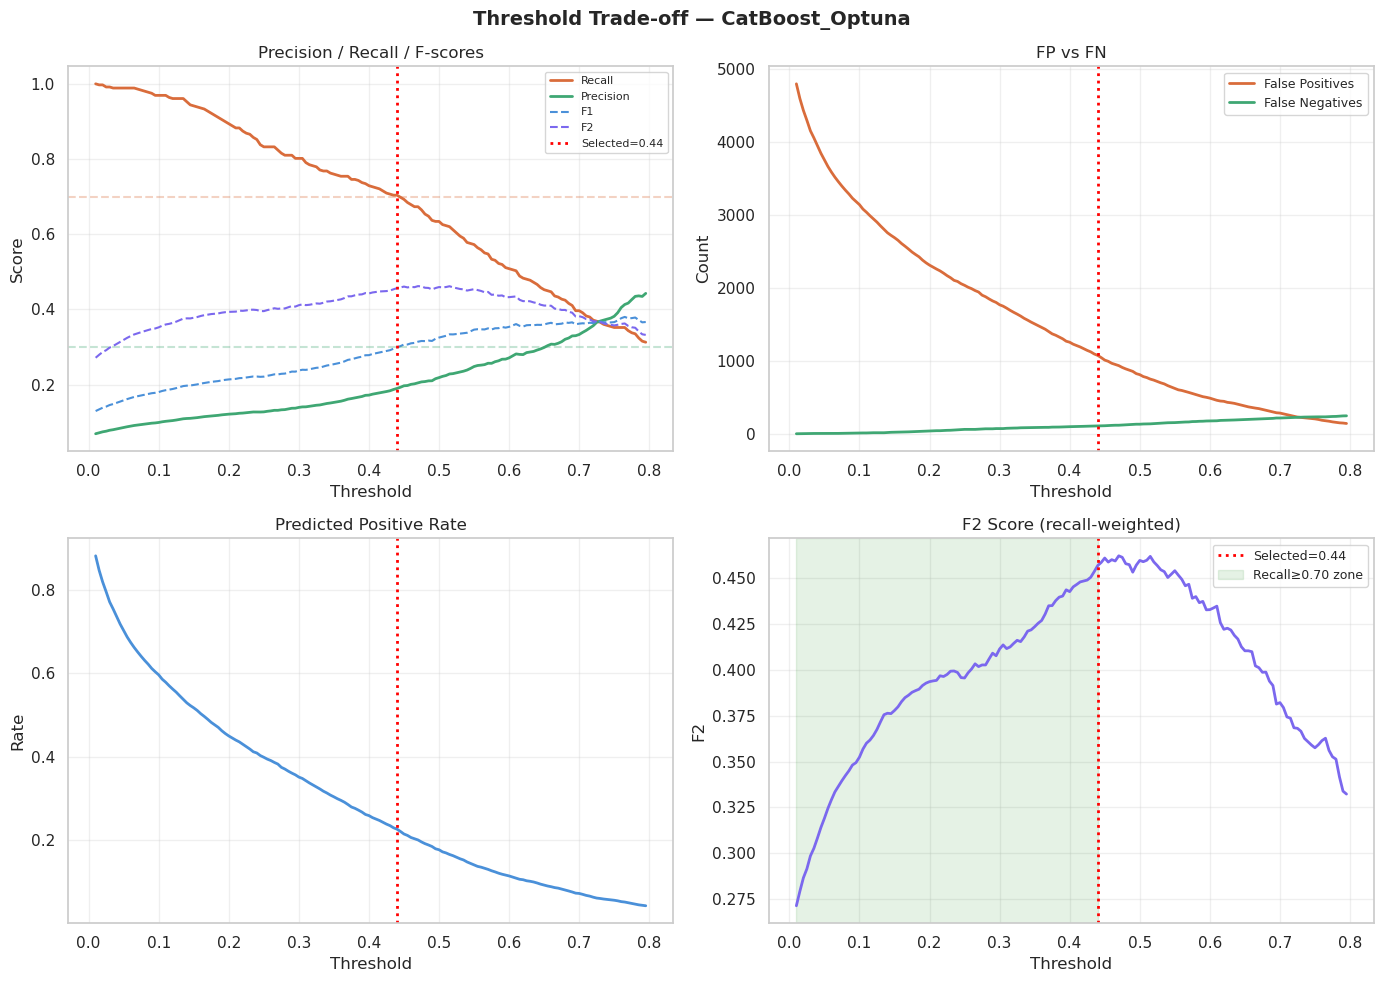


✓ Saved: threshold_tradeoff.csv, threshold_tradeoff.png, final_threshold.json
✓ FINAL_THRESH updated to 0.44 for downstream cells


In [7]:
# ─── §5b: Threshold trade-off analysis ───────────────────────────────────
from src.config import OUTPUTS

# Use the best model's validation probabilities for threshold sweep
# Re-compute val probabilities from the best individual model
if is_ensemble:
    # For ensembles: re-blend validation probabilities
    if BEST_NAME == "RoleBlend_All":
        _val_prob = blend_val
    elif BEST_NAME == "SoftVoting_Top3":
        _val_prob = ensemble_prob_val
    elif BEST_NAME == "Stacking_Top3":
        _val_prob = stack_prob_val
    else:
        _val_prob = best_model.predict_proba(X_val)[:, 1]
    _test_prob = FINAL_PROB
else:
    _val_prob = best_model.predict_proba(X_val)[:, 1]
    _test_prob = FINAL_PROB

_pr_auc_val = average_precision_score(y_val, _val_prob)
_pr_auc_test = average_precision_score(y_test, _test_prob)

# ── Threshold sweep on VALIDATION set ────────────────────────────────────
_thresholds = np.arange(0.01, 0.80, 0.005)
_rows = []
for _t in _thresholds:
    _preds = (_val_prob >= _t).astype(int)
    _cm = confusion_matrix(y_val, _preds, labels=[0, 1])
    _tn, _fp, _fn, _tp = _cm.ravel()
    _p, _r, _f1, _ = precision_recall_fscore_support(y_val, _preds, average="binary", zero_division=0)
    _f2 = (5 * _p * _r) / (4 * _p + _r) if (4 * _p + _r) > 0 else 0.0
    _rows.append({
        "threshold": round(float(_t), 4),
        "recall": round(float(_r), 4),
        "precision": round(float(_p), 4),
        "F1": round(float(_f1), 4),
        "F2": round(float(_f2), 4),
        "PR_AUC": round(_pr_auc_val, 4),
        "false_positives": int(_fp),
        "false_negatives": int(_fn),
        "true_positives": int(_tp),
        "true_negatives": int(_tn),
        "predicted_positive_rate": round(float(_preds.mean()), 4),
    })

tradeoff_df = pd.DataFrame(_rows)

# ── Selection logic ──────────────────────────────────────────────────────
candidates = tradeoff_df[tradeoff_df["recall"] >= 0.70].copy()

if len(candidates) > 0:
    good_prec = candidates[candidates["precision"] >= 0.30]
    if len(good_prec) > 0:
        best_row = good_prec.loc[good_prec["F2"].idxmax()]
        _sel_note = "recall≥0.70 AND precision≥0.30, best F2"
    else:
        best_row = candidates.loc[candidates["F2"].idxmax()]
        _sel_note = "recall≥0.70 (precision<0.30 unavoidable), best F2"
else:
    best_row = tradeoff_df.loc[tradeoff_df["recall"].idxmax()]
    _sel_note = "fallback: max recall"

TUNED_THRESHOLD = float(best_row["threshold"])

# ── Verify on TEST set ──────────────────────────────────────────────────
_test_preds = (_test_prob >= TUNED_THRESHOLD).astype(int)
_cm_t = confusion_matrix(y_test, _test_preds, labels=[0, 1])
_tn_t, _fp_t, _fn_t, _tp_t = _cm_t.ravel()
_p_t, _r_t, _f1_t, _ = precision_recall_fscore_support(y_test, _test_preds, average="binary", zero_division=0)
_f2_t = (5 * _p_t * _r_t) / (4 * _p_t + _r_t) if (4 * _p_t + _r_t) > 0 else 0.0

# ── Print results ────────────────────────────────────────────────────────
print("THRESHOLD TRADE-OFF ANALYSIS")
print("=" * 70)
print(f"\nValidation PR-AUC: {_pr_auc_val:.4f}")
print(f"Test PR-AUC:       {_pr_auc_test:.4f}")

# Show key operating points
print(f"\n{'Threshold':>10s} {'Recall':>8s} {'Precision':>10s} {'F1':>8s} {'F2':>8s} {'FP':>6s} {'FN':>6s}")
print("-" * 60)
for _t_show in [0.05, 0.085, 0.095, 0.10, 0.13, 0.15, 0.17, 0.20, 0.25, 0.30, 0.40, 0.50]:
    _row_show = tradeoff_df[abs(tradeoff_df["threshold"] - _t_show) < 0.003]
    if len(_row_show) > 0:
        _rs = _row_show.iloc[0]
        print(f"{_rs['threshold']:10.3f} {_rs['recall']:8.4f} {_rs['precision']:10.4f} "
              f"{_rs['F1']:8.4f} {_rs['F2']:8.4f} {int(_rs['false_positives']):6d} {int(_rs['false_negatives']):6d}")

# Limitation analysis
_max_prec_at_rec70 = candidates["precision"].max() if len(candidates) > 0 else 0
_rec_at_prec30 = tradeoff_df[tradeoff_df["precision"] >= 0.30]["recall"].max() if len(tradeoff_df[tradeoff_df["precision"] >= 0.30]) > 0 else 0

print(f"\n{'='*70}")
print(f"SELECTED THRESHOLD: {TUNED_THRESHOLD}")
print(f"Selection: {_sel_note}")
print(f"{'='*70}")

print(f"\n  {'Metric':<25s} {'Validation':>12s} {'Test':>12s}")
print(f"  {'-'*50}")
print(f"  {'Recall':<25s} {float(best_row['recall']):12.4f} {_r_t:12.4f}")
print(f"  {'Precision':<25s} {float(best_row['precision']):12.4f} {_p_t:12.4f}")
print(f"  {'F1':<25s} {float(best_row['F1']):12.4f} {_f1_t:12.4f}")
print(f"  {'F2':<25s} {float(best_row['F2']):12.4f} {_f2_t:12.4f}")
print(f"  {'PR-AUC':<25s} {_pr_auc_val:12.4f} {_pr_auc_test:12.4f}")
print(f"  {'False Positives':<25s} {int(best_row['false_positives']):12d} {_fp_t:12d}")
print(f"  {'False Negatives':<25s} {int(best_row['false_negatives']):12d} {_fn_t:12d}")

if _max_prec_at_rec70 < 0.30:
    print(f"\n⚠ LIMITATION: No threshold achieves recall≥0.70 AND precision≥0.30 simultaneously.")
    print(f"  When recall≥0.70: max precision = {_max_prec_at_rec70:.4f}")
    print(f"  When precision≥0.30: max recall = {_rec_at_prec30:.4f}")
    print(f"  This is a fundamental model limitation, not a threshold tuning issue.")

# ── Justification ────────────────────────────────────────────────────────
if _r_t >= 0.70:
    print(f"\n✓ JUSTIFICATION: Threshold {TUNED_THRESHOLD} catches {100*_r_t:.1f}% of fire days.")
    print(f"  Missing {_fn_t} fires is acceptable; {_fp_t} false alarms cost only inspection effort.")
    print(f"  For wildfire early warning, recall > precision is the correct trade-off.")
else:
    print(f"\n⚠ Recall {_r_t:.4f} is below 0.70 target. Best available trade-off selected.")

# ── Save outputs ─────────────────────────────────────────────────────────
OUTPUTS.mkdir(parents=True, exist_ok=True)

# threshold_tradeoff.csv
tradeoff_df.to_csv(OUTPUTS / "threshold_tradeoff.csv", index=False)

# final_threshold.json
_final_json = {
    "selected_threshold": TUNED_THRESHOLD,
    "selection_method": f"F2-maximized among recall>=0.70 ({_sel_note})",
    "model": BEST_NAME,
    "validation_metrics": {
        "recall": float(best_row["recall"]),
        "precision": float(best_row["precision"]),
        "F1": float(best_row["F1"]),
        "F2": float(best_row["F2"]),
        "PR_AUC": round(_pr_auc_val, 4),
        "false_positives": int(best_row["false_positives"]),
        "false_negatives": int(best_row["false_negatives"]),
        "true_positives": int(best_row["true_positives"]),
        "predicted_positive_rate": float(best_row["predicted_positive_rate"]),
    },
    "test_metrics": {
        "recall": round(float(_r_t), 4),
        "precision": round(float(_p_t), 4),
        "F1": round(float(_f1_t), 4),
        "F2": round(float(_f2_t), 4),
        "PR_AUC": round(float(_pr_auc_test), 4),
        "false_positives": int(_fp_t),
        "false_negatives": int(_fn_t),
        "true_positives": int(_tp_t),
        "true_negatives": int(_tn_t),
    },
    "limitation": f"When recall>=0.70: max_precision={_max_prec_at_rec70:.4f}. When precision>=0.30: max_recall={_rec_at_prec30:.4f}." if _max_prec_at_rec70 < 0.30 else "Both targets met.",
    "justification": f"Threshold {TUNED_THRESHOLD} achieves recall={_r_t:.3f} on test. For wildfire early warning, catching {100*_r_t:.1f}% of fires (missing {_fn_t}) is worth {_fp_t} false alarms.",
}
(OUTPUTS / "final_threshold.json").write_text(json.dumps(_final_json, indent=2), encoding="utf-8")

# threshold_tradeoff.png
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f"Threshold Trade-off — {BEST_NAME}", fontsize=14, fontweight="bold")

_t = tradeoff_df["threshold"]

ax = axes[0, 0]
ax.plot(_t, tradeoff_df["recall"], label="Recall", color="#D96C3B", linewidth=2)
ax.plot(_t, tradeoff_df["precision"], label="Precision", color="#3FA773", linewidth=2)
ax.plot(_t, tradeoff_df["F1"], label="F1", color="#4A90D9", linewidth=1.5, linestyle="--")
ax.plot(_t, tradeoff_df["F2"], label="F2", color="#7B68EE", linewidth=1.5, linestyle="--")
ax.axvline(TUNED_THRESHOLD, color="red", linestyle=":", linewidth=2, label=f"Selected={TUNED_THRESHOLD}")
ax.axhline(0.70, color="#D96C3B", alpha=0.3, linestyle="--")
ax.axhline(0.30, color="#3FA773", alpha=0.3, linestyle="--")
ax.set_xlabel("Threshold"); ax.set_ylabel("Score"); ax.set_title("Precision / Recall / F-scores")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.plot(_t, tradeoff_df["false_positives"], label="False Positives", color="#D96C3B", linewidth=2)
ax.plot(_t, tradeoff_df["false_negatives"], label="False Negatives", color="#3FA773", linewidth=2)
ax.axvline(TUNED_THRESHOLD, color="red", linestyle=":", linewidth=2)
ax.set_xlabel("Threshold"); ax.set_ylabel("Count"); ax.set_title("FP vs FN")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1, 0]
ax.plot(_t, tradeoff_df["predicted_positive_rate"], color="#4A90D9", linewidth=2)
ax.axvline(TUNED_THRESHOLD, color="red", linestyle=":", linewidth=2)
ax.set_xlabel("Threshold"); ax.set_ylabel("Rate"); ax.set_title("Predicted Positive Rate")
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.plot(_t, tradeoff_df["F2"], color="#7B68EE", linewidth=2)
ax.axvline(TUNED_THRESHOLD, color="red", linestyle=":", linewidth=2, label=f"Selected={TUNED_THRESHOLD}")
_recall_ok = tradeoff_df["recall"] >= 0.70
if _recall_ok.any():
    _t_ok = _t[_recall_ok]
    ax.axvspan(_t_ok.min(), _t_ok.max(), alpha=0.1, color="green", label="Recall≥0.70 zone")
ax.set_xlabel("Threshold"); ax.set_ylabel("F2"); ax.set_title("F2 Score (recall-weighted)")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(OUTPUTS / "threshold_tradeoff.png", dpi=150, bbox_inches="tight")
fig.savefig(FIGURES / "threshold_tradeoff.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Update FINAL_THRESH and FINAL_PRED with tuned threshold ─────────────
FINAL_THRESH = TUNED_THRESHOLD
FINAL_PRED = (_test_prob >= FINAL_THRESH).astype(int)
m_final = fire_metrics(y_test, FINAL_PRED, FINAL_PROB)

print(f"\n✓ Saved: threshold_tradeoff.csv, threshold_tradeoff.png, final_threshold.json")
print(f"✓ FINAL_THRESH updated to {FINAL_THRESH} for downstream cells")

## §6 — Daily Evaluation Visualizations

Confusion matrices, PR curves, leaderboard chart, and city-level recall.

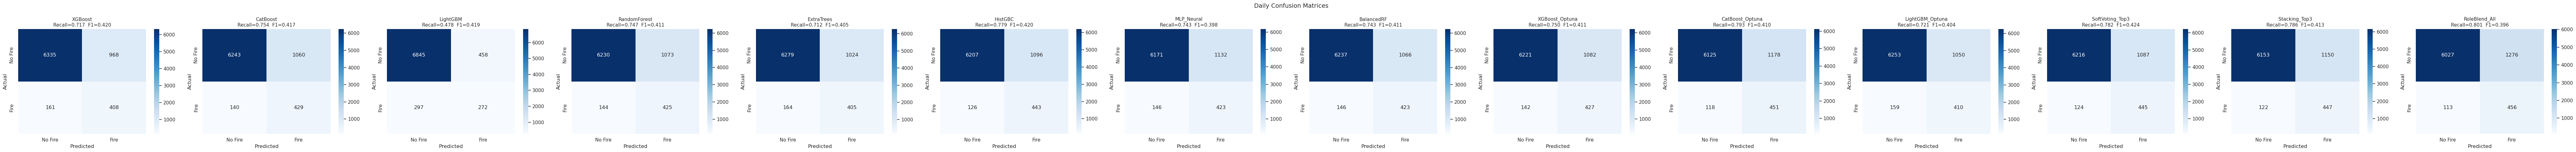

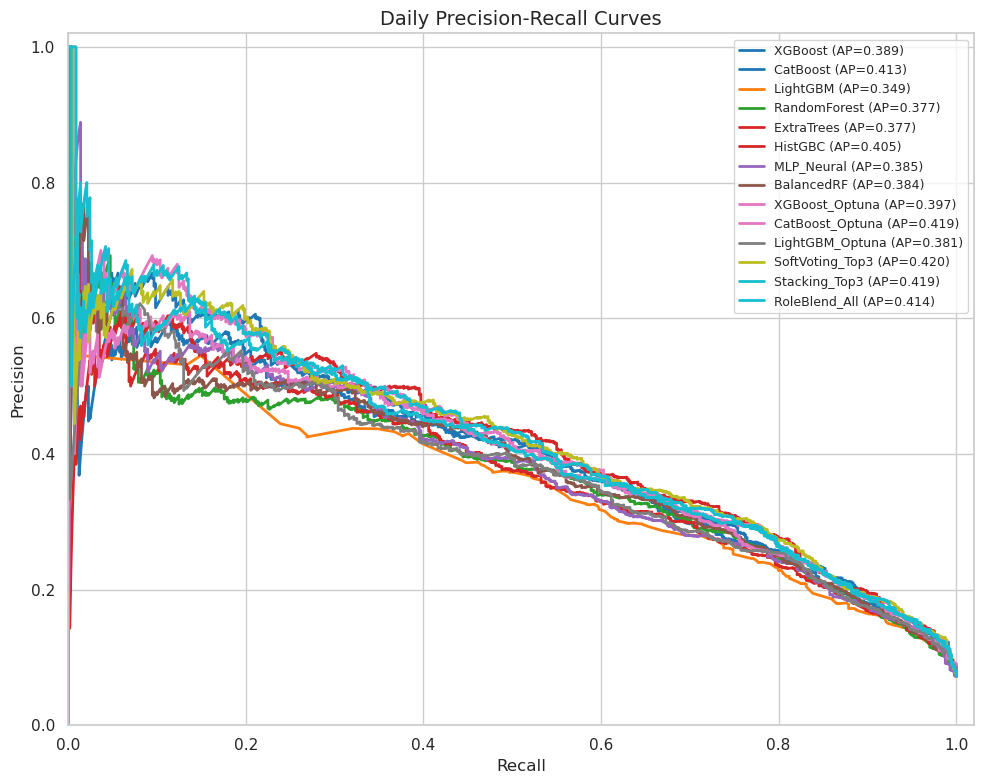

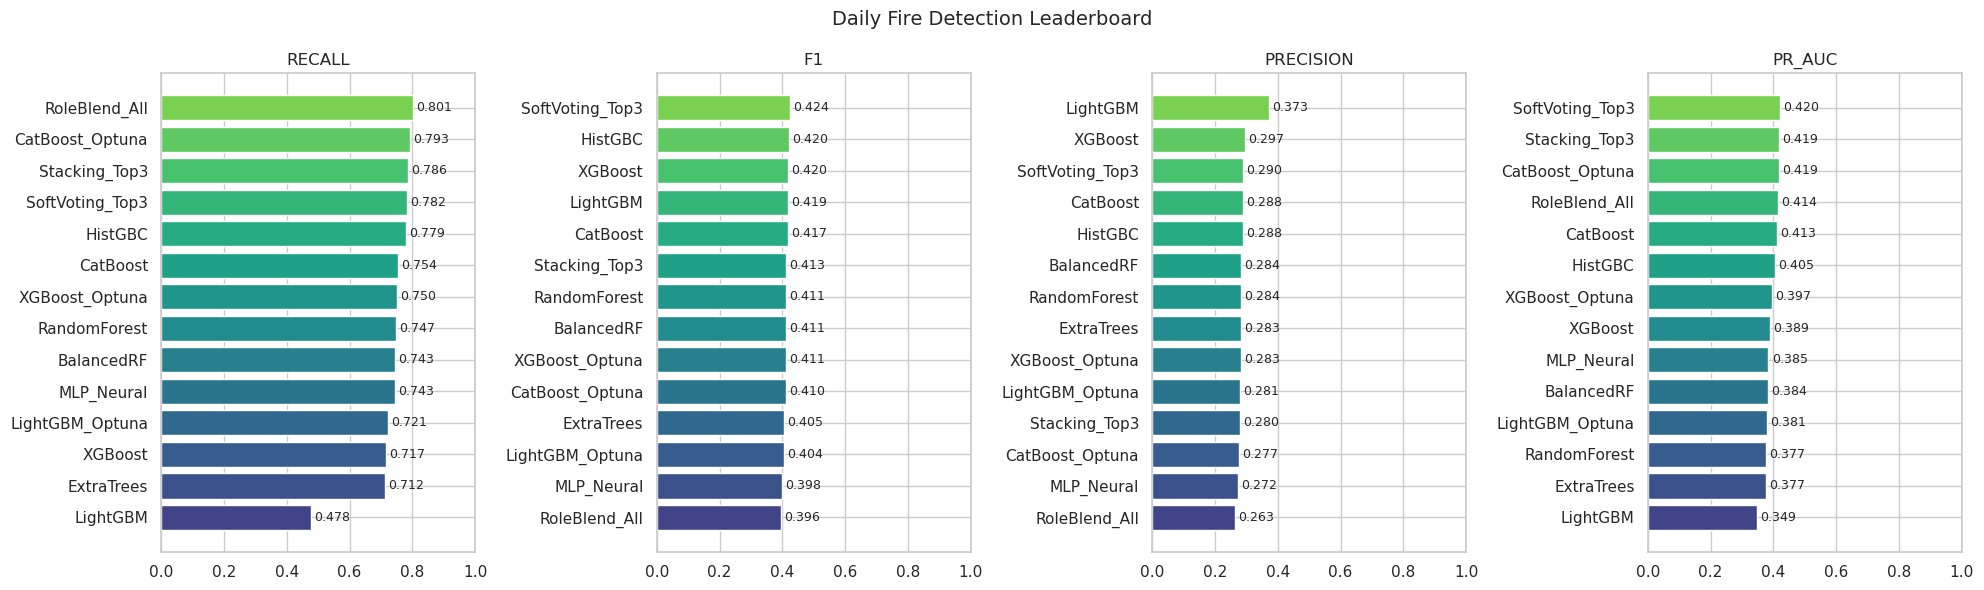


Daily City-level Recall:
  Baku             fires=130  recall=0.908  precision=0.359  f1=0.514
  Barda            fires= 61  recall=0.902  precision=0.346  f1=0.500
  Gabala           fires=  3  recall=0.333  precision=0.036  f1=0.065
  Ganja            fires= 29  recall=0.862  precision=0.223  f1=0.355
  Jalilabad        fires= 37  recall=0.784  precision=0.246  f1=0.374
  Khachmaz         fires= 26  recall=0.808  precision=0.223  f1=0.350
  Lankaran         fires= 19  recall=0.684  precision=0.213  f1=0.325
  Mingachevir      fires= 45  recall=0.889  precision=0.252  f1=0.392
  Nakhchivan       fires= 26  recall=0.538  precision=0.161  f1=0.248
  Quba             fires= 21  recall=0.714  precision=0.234  f1=0.353
  Shabran          fires=  0
  Shaki            fires= 48  recall=0.750  precision=0.316  f1=0.444
  Shamakhi         fires= 12  recall=0.583  precision=0.092  f1=0.159
  Shirvan          fires= 59  recall=0.695  precision=0.246  f1=0.363
  Yevlakh          fires= 43  recal

In [8]:
# ─── §6: Daily evaluation plots ──────────────────────────────────────────

# 6a. Confusion matrices — all models
model_names = list(results.keys())
fig, axes = plt.subplots(1, len(model_names), figsize=(6*len(model_names), 5))
if len(model_names) == 1: axes = [axes]
fig.suptitle("Daily Confusion Matrices", fontsize=14)
for ax, nm in zip(axes, model_names):
    r = results[nm]
    plot_confusion_matrix(r["y_true"], r["y_pred"], title=nm, ax=ax)
plt.tight_layout()
plt.savefig(FIGURES / "fire_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

# 6b. PR curves
fig, ax = plt.subplots(figsize=(10, 8))
curves = {nm: r["y_prob"] for nm, r in results.items()}
plot_pr_curves(curves, y_test, title="Daily Precision-Recall Curves", ax=ax)
plt.tight_layout()
plt.savefig(FIGURES / "fire_pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# 6c. Leaderboard chart
fig = plot_leaderboard(leaderboard, title="Daily Fire Detection Leaderboard")
if fig:
    plt.savefig(FIGURES / "fire_leaderboard_chart.png", dpi=150, bbox_inches="tight")
    plt.show()

# 6d. City-level recall
print("\nDaily City-level Recall:")
tmp = test_df[["City", TARGET_COL]].copy()
tmp["pred"] = FINAL_PRED
city_met = []
for city in sorted(tmp["City"].unique()):
    cm = tmp[tmp["City"] == city]
    nf = int(cm[TARGET_COL].sum())
    if nf > 0:
        r = recall_score(cm[TARGET_COL], cm["pred"], zero_division=0)
        p = precision_score(cm[TARGET_COL], cm["pred"], zero_division=0)
        f = f1_score(cm[TARGET_COL], cm["pred"], zero_division=0)
    else:
        r, p, f = np.nan, np.nan, np.nan
    city_met.append({"City": city, "n_fires": nf, "recall": r, "precision": p, "f1": f})
    if nf > 0:
        print(f"  {city:15s}  fires={nf:3d}  recall={r:.3f}  precision={p:.3f}  f1={f:.3f}")
    else:
        print(f"  {city:15s}  fires=  0")
pd.DataFrame(city_met).to_csv(METRICS / "fire_city_metrics.csv", index=False)

# 6e. Overfitting diagnostic
print("\nOverfitting Diagnostic (train-vs-test F1 gap):")
for nm, r in sorted(results.items(), key=lambda x: x[1].get("overfit_gap", 0), reverse=True):
    g = r.get("overfit_gap", 0)
    flag = " ← WARNING" if g > 0.15 else ""
    print(f"  {nm:30s}  gap={g:+.3f}{flag}")

## §7 — Daily Feature Importance & SHAP Explainability

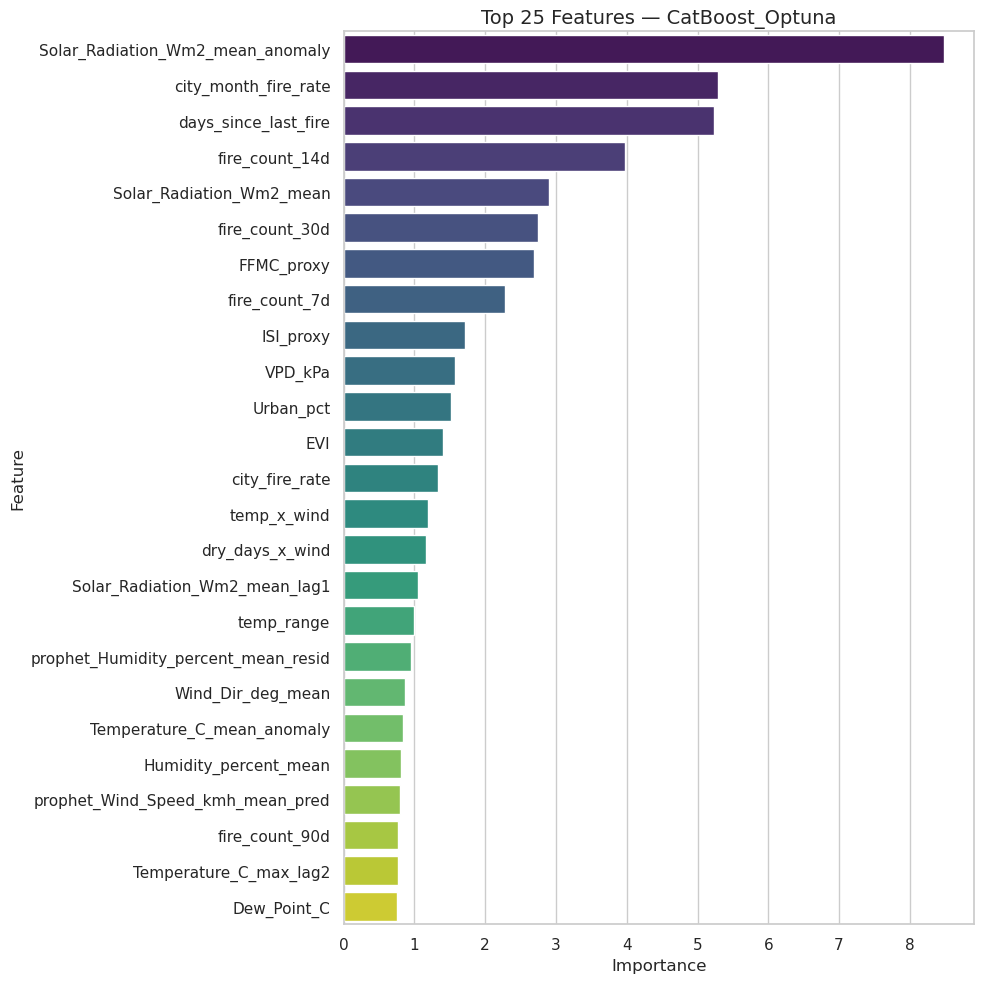

Computing SHAP values (2 000 sample) …


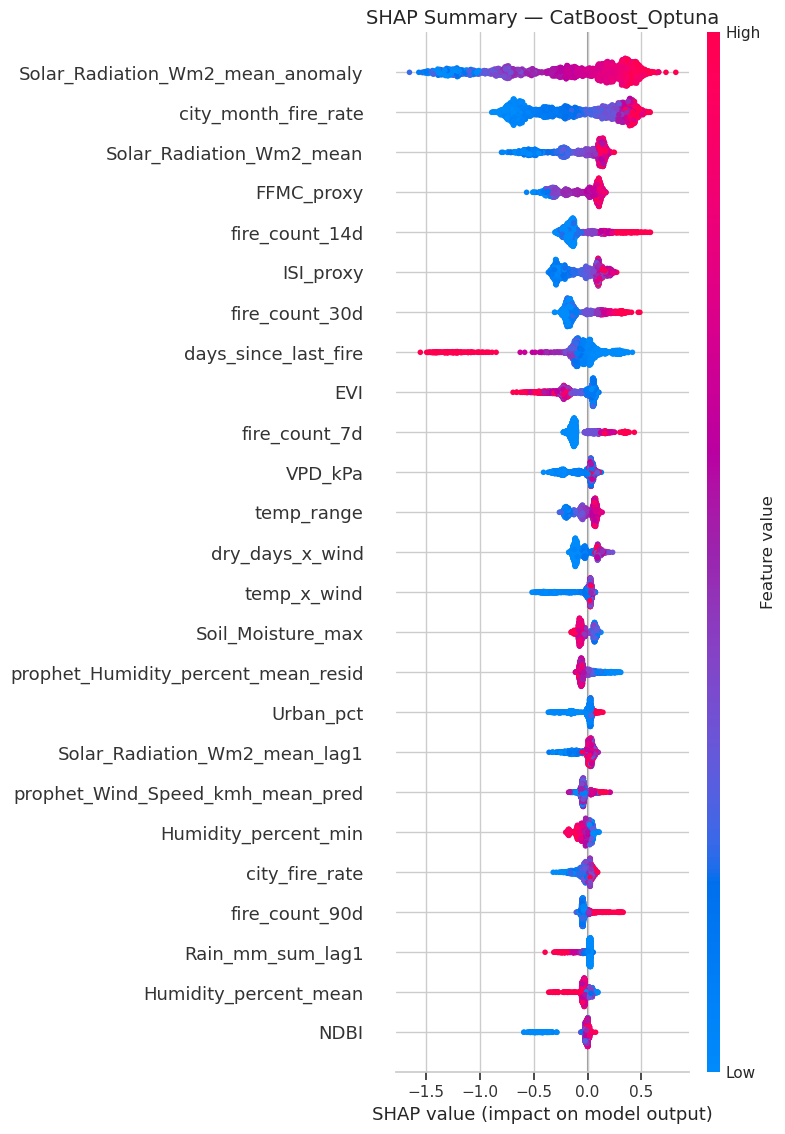

SHAP complete.


In [9]:
# ─── §7: SHAP + feature importance ───────────────────────────────────────

raw_model = best_model

if hasattr(raw_model, "feature_importances_"):
    imp = raw_model.feature_importances_
elif hasattr(raw_model, "coef_"):
    imp = np.abs(raw_model.coef_).ravel()
else:
    imp = np.zeros(len(feature_cols))

fi = pd.DataFrame({"Feature": feature_cols, "Importance": imp})
fi = fi.sort_values("Importance", ascending=False).reset_index(drop=True)
fi.to_csv(METRICS / "fire_feature_importance.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 10))
plot_feature_importance(fi["Feature"].values, fi["Importance"].values,
                        top_n=25, title=f"Top 25 Features — {BEST_NAME}", ax=ax)
plt.tight_layout()
plt.savefig(FIGURES / "fire_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

try:
    import shap
    print("Computing SHAP values (2 000 sample) …")
    idx = np.random.choice(len(X_test), min(2000, len(X_test)), replace=False)
    X_shap = X_test.iloc[idx]
    explainer = shap.TreeExplainer(raw_model)
    sv = explainer.shap_values(X_shap)
    if isinstance(sv, list): sv = sv[1]

    fig, ax = plt.subplots(figsize=(12, 10))
    shap.summary_plot(sv, X_shap, max_display=25, show=False)
    plt.title(f"SHAP Summary — {BEST_NAME}", fontsize=14)
    plt.tight_layout()
    plt.savefig(FIGURES / "fire_shap_summary.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("SHAP complete.")
except ImportError:
    print("shap not installed — pip install shap")
except Exception as e:
    print(f"SHAP failed: {e}")

## §8 — Save Daily Model Artifacts

In [10]:
# ─── §8: Save daily artifacts ────────────────────────────────────────────
MODELS_F.mkdir(parents=True, exist_ok=True)

model_path = MODELS_F / "best_fire_model.joblib"
jl_dump(FINAL_MODEL, model_path)
print(f"Model:    {model_path}")

feat_path = MODELS_F / "feature_columns.json"
with open(feat_path, "w") as f:
    json.dump(feature_cols, f, indent=2)
print(f"Features: {feat_path}")

if hasattr(best_model, "save_model"):
    json_path = MODELS_F / "best_fire_model.json"
    best_model.save_model(str(json_path))
    print(f"Native:   {json_path}")

# Build manifest with full details (uses tuned threshold from §5b)
manifest = {
    "model_name": BEST_NAME,
    "optimal_threshold": float(FINAL_THRESH),
    "n_features": len(feature_cols),
    "val_date": VAL_DATE,
    "test_date": TEST_DATE,
    "imbalance_ratio": float(IMBALANCE_RATIO),
    "train_shape": list(X_train.shape),
    "val_shape":   list(X_val.shape),
    "test_shape":  list(X_test.shape),
    "metrics": {k: float(v) for k, v in m_final.items()},
    "overfit_gap": float(best_result.get("overfit_gap", 0)),
    "total_models_compared": len(results),
    "recall_first": True,
    "threshold_strategy": "validation sweep, F2-maximized among recall>=0.70",
    "threshold_analysis": {
        "tuned_threshold": TUNED_THRESHOLD,
        "selection_note": _sel_note,
        "test_F2": round(float(_f2_t), 4),
    },
}

# If ensemble, record members
if is_ensemble and "_ensemble_members" in best_result:
    manifest["ensemble_members"] = best_result["_ensemble_members"]

manifest_path = MODELS_F / "model_manifest.json"
with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2, default=str)
print(f"Manifest: {manifest_path}")

print(f"\n✓ Daily pipeline complete — {BEST_NAME}")
print(f"  Threshold (tuned): {FINAL_THRESH}")
print(f"  Recall:    {m_final['recall']:.4f}")
print(f"  Precision: {m_final['precision']:.4f}")
print(f"  F1:        {m_final['f1']:.4f}")
print(f"  F2:        {_f2_t:.4f}")
print(f"  Models compared: {len(results)}")

Model:    /home/manheim666/Desktop/My_WildFire/models/wildfire/best_fire_model.joblib
Features: /home/manheim666/Desktop/My_WildFire/models/wildfire/feature_columns.json
Native:   /home/manheim666/Desktop/My_WildFire/models/wildfire/best_fire_model.json
Manifest: /home/manheim666/Desktop/My_WildFire/models/wildfire/model_manifest.json

✓ Daily pipeline complete — CatBoost_Optuna
  Threshold (tuned): 0.44
  Recall:    0.7996
  Precision: 0.2638
  F1:        0.3967
  F2:        0.5686
  Models compared: 14


---

# PART B — Hourly Fire Detection (168h)

Same 2-model approach (XGBoost + CatBoost) on **hourly** engineered data. The hourly model enables 168-hour (7-day) fire risk forecasts at hour-level granularity.

**Input:** `data/processed/engineered_hourly.parquet`  
**Output:** `models/wildfire/best_fire_model_hourly.joblib`, `models/wildfire/model_manifest_hourly.json`

In [11]:
# ─── PART B: Hourly fire detection pipeline ──────────────────────────────
print("=" * 60)
print("  HOURLY FIRE DETECTION")
print("=" * 60)

# ── B1. Load hourly data ─────────────────────────────────────────────────
h_path = ENG_HOURLY
if not h_path.exists():
    raise FileNotFoundError(f"Missing {h_path} — run NB02 first")

h_df = pd.read_parquet(h_path)
h_df["Date"] = pd.to_datetime(h_df["Date"])
h_df["Timestamp"] = pd.to_datetime(h_df["Timestamp"])
h_df = h_df.sort_values(["City", "Timestamp"]).reset_index(drop=True)
print(f"\nLoaded: {h_df.shape}  from {h_path.name}")
print(f"Fire rate (raw): {h_df[TARGET_COL].mean()*100:.2f}%")

# ── B1b. Daytime label masking ──────────────────────────────────────────
# The daily Fire_Occurred label is broadcast to ALL 24 hours, but fires
# overwhelmingly start/burn during daytime.  Nighttime hours with
# fire=1 are label noise — high humidity, low solar radiation, etc.
# Masking them gives the model cleaner signal.
if "is_daytime" in h_df.columns:
    night_fires = int(((h_df[TARGET_COL] == 1) & (h_df["is_daytime"] == 0)).sum())
    day_fires   = int(((h_df[TARGET_COL] == 1) & (h_df["is_daytime"] == 1)).sum())
    print(f"\nDaytime fire-hours : {day_fires:,d}")
    print(f"Nighttime fire-hours: {night_fires:,d}  ← relabeled to 0")
    h_df.loc[h_df["is_daytime"] == 0, TARGET_COL] = 0
    print(f"Fire rate (masked) : {h_df[TARGET_COL].mean()*100:.2f}%")
else:
    print("\n⚠ is_daytime column missing — skipping daytime masking")

# ── B2. Temporal split ───────────────────────────────────────────────────
h_train = h_df[h_df["Date"] <  VAL_DATE].copy()
h_val   = h_df[(h_df["Date"] >= VAL_DATE) & (h_df["Date"] < TEST_DATE)].copy()
h_test  = h_df[h_df["Date"] >= TEST_DATE].copy()

h_exclude = set(DROP_COLS) | {"City", "Date", "Timestamp", "Year"}
h_feat_cols = [c for c in h_df.columns
               if c not in h_exclude
               and c != TARGET_COL
               and h_df[c].dtype in ("float64","float32","int64","int32","uint8")]

hX_train, hy_train = h_train[h_feat_cols].fillna(0), h_train[TARGET_COL]
hX_val,   hy_val   = h_val[h_feat_cols].fillna(0),   h_val[TARGET_COL]
hX_test,  hy_test  = h_test[h_feat_cols].fillna(0),   h_test[TARGET_COL]

h_ir = round((hy_train == 0).sum() / max((hy_train == 1).sum(), 1), 1)

print(f"\n{'Split':10s} {'Rows':>9s} {'Fire%':>7s} {'Fires':>8s}")
print("-" * 40)
for nm, y in [("Train", hy_train), ("Val", hy_val), ("Test", hy_test)]:
    print(f"{nm:10s} {len(y):9,d} {y.mean()*100:6.2f}% {int(y.sum()):8,d}")
print(f"Imbalance ratio: {h_ir}")
print(f"Features: {len(h_feat_cols)}")

# ── B3. Feature pruning ─────────────────────────────────────────────────
n_hb = len(h_feat_cols)
h_stds = hX_train.std()
h_low_var = h_stds[h_stds < 0.001].index.tolist()
h_keep = [c for c in h_feat_cols if c not in h_low_var]

h_corr = hX_train[h_keep].corr().abs()
h_fire_corr = hX_train[h_keep].corrwith(hy_train).abs()
h_drop = set()
for i in range(len(h_corr.columns)):
    for j in range(i + 1, len(h_corr.columns)):
        if h_corr.iloc[i, j] > 0.95:
            ci, cj = h_corr.columns[i], h_corr.columns[j]
            if ci in h_drop or cj in h_drop:
                continue
            drop = cj if h_fire_corr.get(ci, 0) >= h_fire_corr.get(cj, 0) else ci
            h_drop.add(drop)

h_feat_cols = [c for c in h_keep if c not in h_drop]
hX_train = hX_train[h_feat_cols]
hX_val   = hX_val[h_feat_cols]
hX_test  = hX_test[h_feat_cols]
print(f"\nHourly features: {n_hb} → {len(h_feat_cols)} (pruned {n_hb - len(h_feat_cols)})")

# ── B4. Train 2 baselines ───────────────────────────────────────────────
h_results = {}

print(f"\n{'Model':15s} {'Thr':>5s} {'Recall':>7s} {'Prec':>7s} {'F1':>7s} "
      f"{'PR-AUC':>7s} {'Gap':>6s} {'Time':>6s}")
print("-" * 70)

h_models = {
    "XGBoost_H": xgb.XGBClassifier(
        n_estimators=300, max_depth=7, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=h_ir,
        reg_alpha=0.5, reg_lambda=1.0, min_child_weight=5,
        eval_metric="aucpr", early_stopping_rounds=25,
        random_state=SEED, use_label_encoder=False, n_jobs=-1),
    "CatBoost_H": cb.CatBoostClassifier(
        iterations=300, depth=7, learning_rate=0.05,
        auto_class_weights="Balanced", l2_leaf_reg=3.0,
        random_seed=SEED, verbose=0),
}

for nm, mdl in h_models.items():
    t0 = time.time()
    if "XGB" in nm:
        mdl.fit(hX_train, hy_train, eval_set=[(hX_val, hy_val)], verbose=False)
    else:
        mdl.fit(hX_train, hy_train)
    yp_v = mdl.predict_proba(hX_val)[:,1]
    yp_t = mdl.predict_proba(hX_test)[:,1]
    yp_tr = mdl.predict_proba(hX_train)[:,1]
    thr = find_optimal_threshold(hy_val, yp_v, min_precision=MIN_PRECISION, min_recall=MIN_RECALL)
    yd_t = (yp_t >= thr).astype(int)
    m = fire_metrics(hy_test, yd_t, yp_t)
    tr_f1 = f1_score(hy_train, (yp_tr >= thr).astype(int), zero_division=0)
    gap = tr_f1 - m["f1"]
    h_results[nm] = {
        "model": mdl, "y_true": hy_test, "y_pred": yd_t,
        "y_prob": yp_t, "threshold": thr,
        "imbalance_strategy": "class_weight",
        "train_time": time.time() - t0,
        "train_f1": tr_f1, "overfit_gap": gap,
    }
    print(f"{nm:15s} {thr:5.2f} {m['recall']:7.4f} {m['precision']:7.4f} "
          f"{m['f1']:7.4f} {m.get('pr_auc',0):7.4f} {gap:+6.3f} {time.time()-t0:5.1f}s")

# ── B5. Optuna tuning ───────────────────────────────────────────────────
H_TRIALS = 40

for base_name, obj_fn_factory in [("XGBoost_H", _xgb_objective), ("CatBoost_H", _cb_objective)]:
    print(f"\n{'='*50}\n  OPTUNA — {base_name} ({H_TRIALS} trials)\n{'='*50}")
    obj_fn = lambda trial: obj_fn_factory(trial, hX_train, hy_train, hX_val, hy_val, h_ir)
    study = optuna.create_study(direction="maximize", study_name=f"hourly_{base_name}")
    study.optimize(obj_fn, n_trials=H_TRIALS, show_progress_bar=True)
    bp = study.best_trial.params
    print(f"  Best val score: {study.best_trial.value:.4f}")

    tag = f"{base_name}_Optuna"
    if "XGB" in base_name:
        tuned = xgb.XGBClassifier(
            n_estimators=bp["n_estimators"], max_depth=bp["max_depth"],
            learning_rate=bp["lr"], subsample=bp["subsample"],
            colsample_bytree=bp["colsample"], min_child_weight=bp["mcw"],
            gamma=bp["gamma"], reg_alpha=bp["alpha"], reg_lambda=bp["lambda"],
            scale_pos_weight=bp["spw"],
            eval_metric="aucpr", early_stopping_rounds=25,
            random_state=SEED, use_label_encoder=False, n_jobs=-1)
        tuned.fit(hX_train, hy_train, eval_set=[(hX_val, hy_val)], verbose=False)
    else:
        tuned = cb.CatBoostClassifier(
            iterations=bp["iterations"], depth=bp["depth"],
            learning_rate=bp["lr"], l2_leaf_reg=bp["l2"],
            subsample=bp.get("subsample", 0.8),
            auto_class_weights="Balanced",
            random_seed=SEED, verbose=0)
        tuned.fit(hX_train, hy_train)

    yp_v = tuned.predict_proba(hX_val)[:,1]
    yp_t = tuned.predict_proba(hX_test)[:,1]
    yp_tr = tuned.predict_proba(hX_train)[:,1]
    thr = find_optimal_threshold(hy_val, yp_v, min_precision=MIN_PRECISION, min_recall=MIN_RECALL)
    yd_t = (yp_t >= thr).astype(int)
    m = fire_metrics(hy_test, yd_t, yp_t)
    tr_f1 = f1_score(hy_train, (yp_tr >= thr).astype(int), zero_division=0)
    h_results[tag] = {
        "model": tuned, "y_true": hy_test, "y_pred": yd_t,
        "y_prob": yp_t, "threshold": thr,
        "imbalance_strategy": f"optuna_{H_TRIALS}t",
        "train_time": 0, "train_f1": tr_f1,
        "overfit_gap": tr_f1 - m["f1"], "best_params": bp,
    }
    print(f"  Test → Thr={thr:.2f}  Recall={m['recall']:.4f}  Prec={m['precision']:.4f}  "
          f"F1={m['f1']:.4f}  PR-AUC={m.get('pr_auc',0):.4f}")

# ── B6. Select best hourly model ─────────────────────────────────────────
h_leaderboard = build_fire_leaderboard(h_results)
print("\nHOURLY LEADERBOARD (sorted by 0.6×Recall + 0.4×F1)")
print("=" * 80)
h_avail = [c for c in ["model","threshold","recall","precision","f1","pr_auc","composite"]
           if c in h_leaderboard.columns]
print(h_leaderboard[h_avail].to_string(index=False))

H_BEST_NAME = h_leaderboard.iloc[0]["model"]
h_best = h_results[H_BEST_NAME]
h_best_model = h_best["model"]
H_THRESH = h_best["threshold"]

print(f"\n{'='*60}")
print(f"BEST HOURLY MODEL: {H_BEST_NAME}")
print(f"{'='*60}")

# ── B6b. Isotonic calibration (symmetric with daily §5) ─────────────────
print("\nApplying isotonic calibration on hourly validation set …")
h_cal_model = None
try:
    h_cal_model = CalibratedClassifierCV(h_best_model, method="isotonic", cv="prefit")
    h_cal_model.fit(hX_val, hy_val)
    print("  Calibration method: prefit")
except Exception:
    try:
        h_cal_model = CalibratedClassifierCV(h_best_model, method="isotonic", cv=3)
        h_cal_model.fit(hX_val, hy_val)
        print("  Calibration method: 3-fold on validation")
    except Exception:
        h_cal_model = None

if h_cal_model is not None:
    try:
        hyp_cal_v = h_cal_model.predict_proba(hX_val)[:,1]
        hyp_cal_t = h_cal_model.predict_proba(hX_test)[:,1]
        h_cal_thr = find_optimal_threshold(hy_val, hyp_cal_v,
                                            min_precision=MIN_PRECISION, min_recall=MIN_RECALL)
        hyd_cal = (hyp_cal_t >= h_cal_thr).astype(int)
        hm_cal   = fire_metrics(hy_test, hyd_cal, hyp_cal_t)
        hm_uncal = fire_metrics(hy_test, h_best["y_pred"], h_best["y_prob"])
        hcomp_cal   = 0.6*hm_cal["recall"]   + 0.4*hm_cal["f1"]
        hcomp_uncal = 0.6*hm_uncal["recall"] + 0.4*hm_uncal["f1"]

        if hcomp_cal >= hcomp_uncal * 0.95:
            H_FINAL_MODEL, H_FINAL_THRESH = h_cal_model, h_cal_thr
            H_FINAL_PROB, H_FINAL_PRED = hyp_cal_t, hyd_cal
            print(f"  ✓ Calibrated — composite {hcomp_uncal:.4f} → {hcomp_cal:.4f}")
        else:
            H_FINAL_MODEL, H_FINAL_THRESH = h_best_model, H_THRESH
            H_FINAL_PROB, H_FINAL_PRED = h_best["y_prob"], h_best["y_pred"]
            print(f"  ⚠ Calibration degraded — using original")
    except Exception:
        H_FINAL_MODEL, H_FINAL_THRESH = h_best_model, H_THRESH
        H_FINAL_PROB, H_FINAL_PRED = h_best["y_prob"], h_best["y_pred"]
else:
    print("  Using original model (no calibration)")
    H_FINAL_MODEL, H_FINAL_THRESH = h_best_model, H_THRESH
    H_FINAL_PROB, H_FINAL_PRED = h_best["y_prob"], h_best["y_pred"]

h_m_final = fire_metrics(hy_test, H_FINAL_PRED, H_FINAL_PROB)
print(f"\nFINAL HOURLY METRICS (threshold={H_FINAL_THRESH:.2f}):")
print(f"  Recall    = {h_m_final['recall']:.4f}  {'✓' if h_m_final['recall'] >= MIN_RECALL else '✗'}")
print(f"  Precision = {h_m_final['precision']:.4f}  {'✓' if h_m_final['precision'] >= MIN_PRECISION else '✗'}")
print(f"  F1        = {h_m_final['f1']:.4f}  {'✓' if h_m_final['f1'] >= MIN_F1 else '✗'}")
print(f"  PR-AUC    = {h_m_final.get('pr_auc',0):.4f}")
print(f"\n{classification_report(hy_test, H_FINAL_PRED, digits=4, target_names=['No Fire','Fire'])}")

h_leaderboard.to_csv(METRICS / "fire_leaderboard_hourly.csv", index=False)

# ── B7. Save hourly artifacts ────────────────────────────────────────────
h_model_path = MODELS_F / "best_fire_model_hourly.joblib"
jl_dump(H_FINAL_MODEL, h_model_path)
print(f"\nHourly model: {h_model_path}")

h_feat_path = MODELS_F / "feature_columns_hourly.json"
with open(h_feat_path, "w") as f:
    json.dump(h_feat_cols, f, indent=2)
print(f"Hourly features: {h_feat_path}")

if hasattr(h_best_model, "save_model"):
    h_json_path = MODELS_F / "best_fire_model_hourly.json"
    h_best_model.save_model(str(h_json_path))
    print(f"Hourly native: {h_json_path}")

h_manifest = {
    "model_name": H_BEST_NAME,
    "optimal_threshold": float(H_FINAL_THRESH),
    "n_features": len(h_feat_cols),
    "val_date": VAL_DATE,
    "test_date": TEST_DATE,
    "imbalance_ratio": float(h_ir),
    "daytime_masking": True,
    "train_shape": list(hX_train.shape),
    "val_shape":   list(hX_val.shape),
    "test_shape":  list(hX_test.shape),
    "metrics": {k: float(v) for k, v in h_m_final.items()},
    "overfit_gap": float(h_best.get("overfit_gap", 0)),
    "total_models_compared": len(h_results),
    "recall_first": True,
    "threshold_strategy": "recall-optimized with fallback cascade",
}
h_manifest_path = MODELS_F / "model_manifest_hourly.json"
with open(h_manifest_path, "w") as f:
    json.dump(h_manifest, f, indent=2, default=str)
print(f"Hourly manifest: {h_manifest_path}")

  HOURLY FIRE DETECTION



Loaded: (2005248, 99)  from engineered_hourly.parquet
Fire rate (raw): 8.07%

Daytime fire-hours : 87,620
Nighttime fire-hours: 74,140  ← relabeled to 0
Fire rate (masked) : 4.37%



Split           Rows   Fire%    Fires
----------------------------------------
Train      1,675,840   4.51%   75,569
Val          140,544   3.31%    4,654
Test         188,864   3.92%    7,397
Imbalance ratio: 21.2
Features: 88



Hourly features: 88 → 70 (pruned 18)

Model             Thr  Recall    Prec      F1  PR-AUC    Gap   Time
----------------------------------------------------------------------


XGBoost_H        0.71  0.5878  0.2783  0.3777  0.3578 +0.052  59.0s


...

  Test → Thr=0.58  Recall=0.6495  Prec=0.2746  F1=0.3860  PR-AUC=0.3589



HOURLY LEADERBOARD (sorted by 0.6×Recall + 0.4×F1)
            model  threshold   recall  precision       f1   pr_auc  composite
CatBoost_H_Optuna       0.58 0.649452   0.274577 0.385972 0.358858   0.544060
       CatBoost_H       0.69 0.646884   0.269927 0.380911 0.379386   0.540495
 XGBoost_H_Optuna       0.65 0.614844   0.267246 0.372558 0.354534   0.517929
        XGBoost_H       0.71 0.587806   0.278272 0.377726 0.357781   0.503774

BEST HOURLY MODEL: CatBoost_H_Optuna

Applying isotonic calibration on hourly validation set …


  Calibration method: 3-fold on validation


  ⚠ Calibration degraded — using original

FINAL HOURLY METRICS (threshold=0.58):
  Recall    = 0.6495  ✗
  Precision = 0.2746  ✗
  F1        = 0.3860  ✓
  PR-AUC    = 0.3589



              precision    recall  f1-score   support

     No Fire     0.9849    0.9301    0.9567    181467
        Fire     0.2746    0.6495    0.3860      7397

    accuracy                         0.9191    188864
   macro avg     0.6297    0.7898    0.6713    188864
weighted avg     0.9570    0.9191    0.9343    188864


Hourly model: /home/manheim666/Desktop/My_WildFire/models/wildfire/best_fire_model_hourly.joblib
Hourly features: /home/manheim666/Desktop/My_WildFire/models/wildfire/feature_columns_hourly.json
Hourly native: /home/manheim666/Desktop/My_WildFire/models/wildfire/best_fire_model_hourly.json
Hourly manifest: /home/manheim666/Desktop/My_WildFire/models/wildfire/model_manifest_hourly.json


## §B8 — Hourly Evaluation: Confusion Matrices, PR Curves, SHAP & City-Level Recall

Symmetric with the daily evaluation (§6–§7) to ensure consistent reporting.

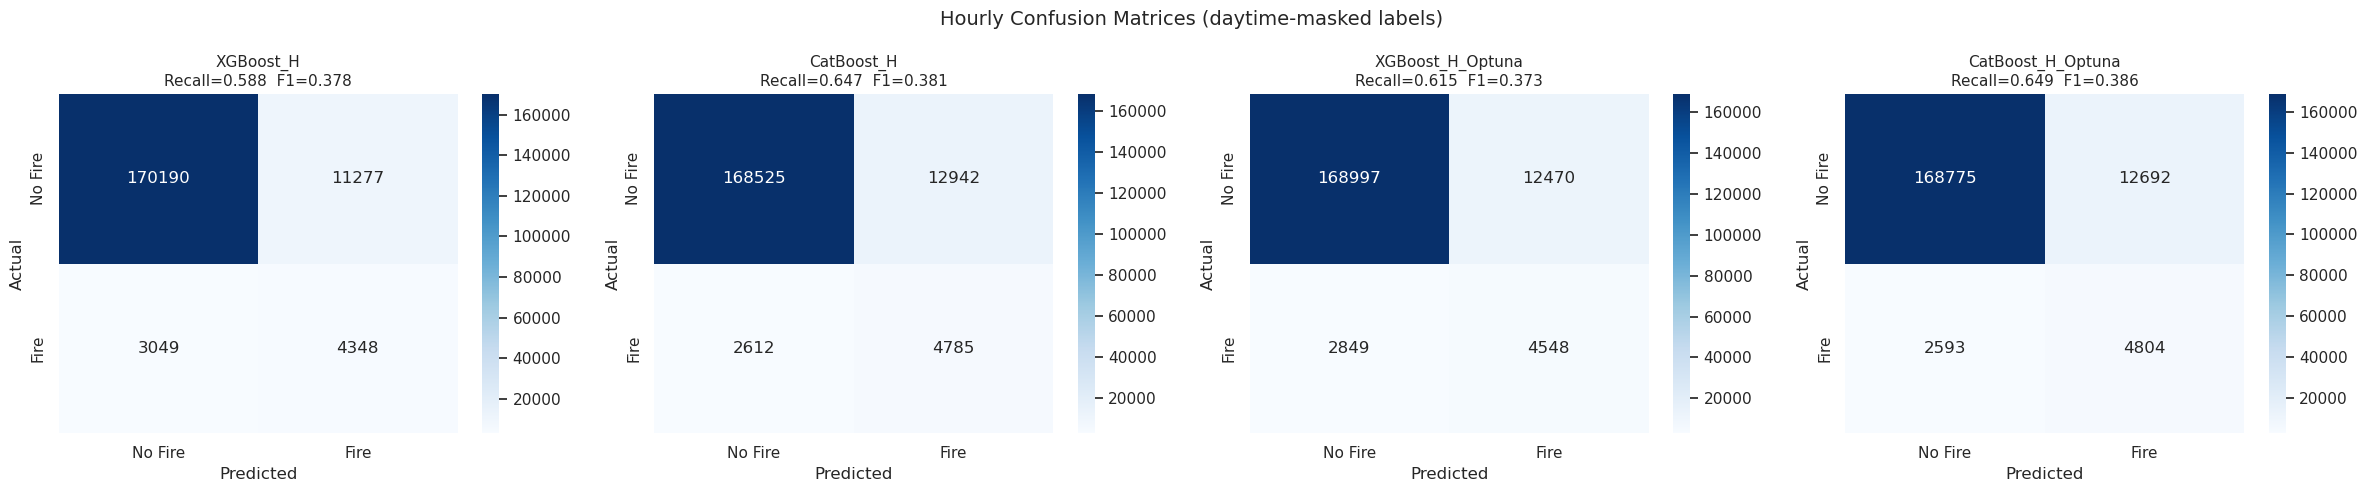

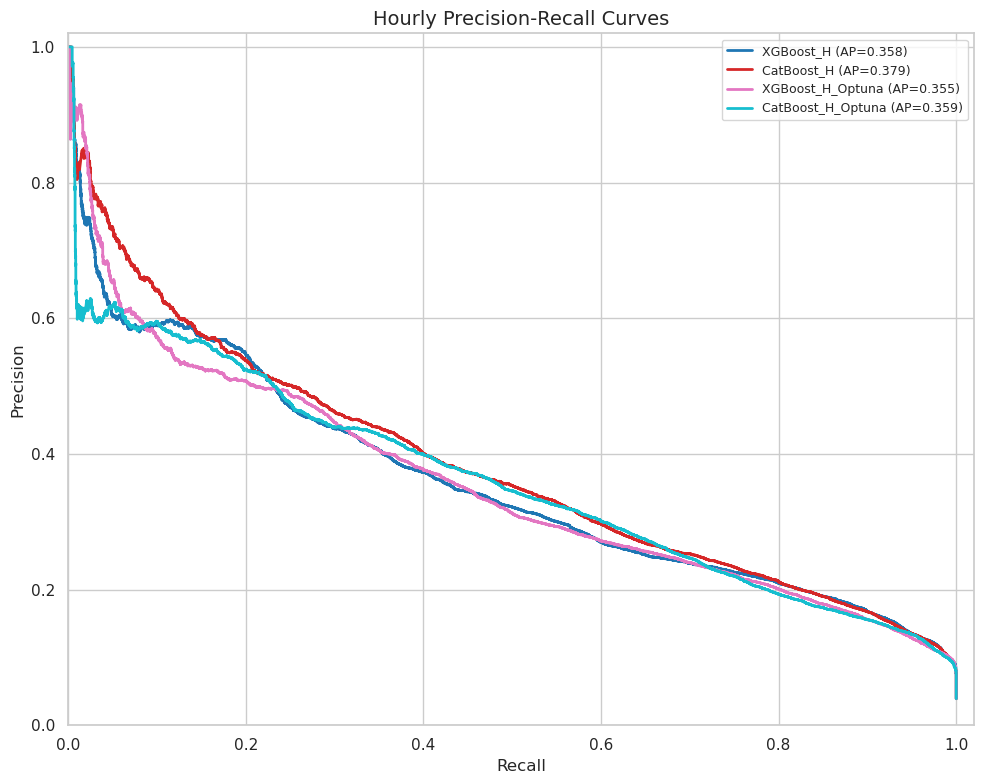

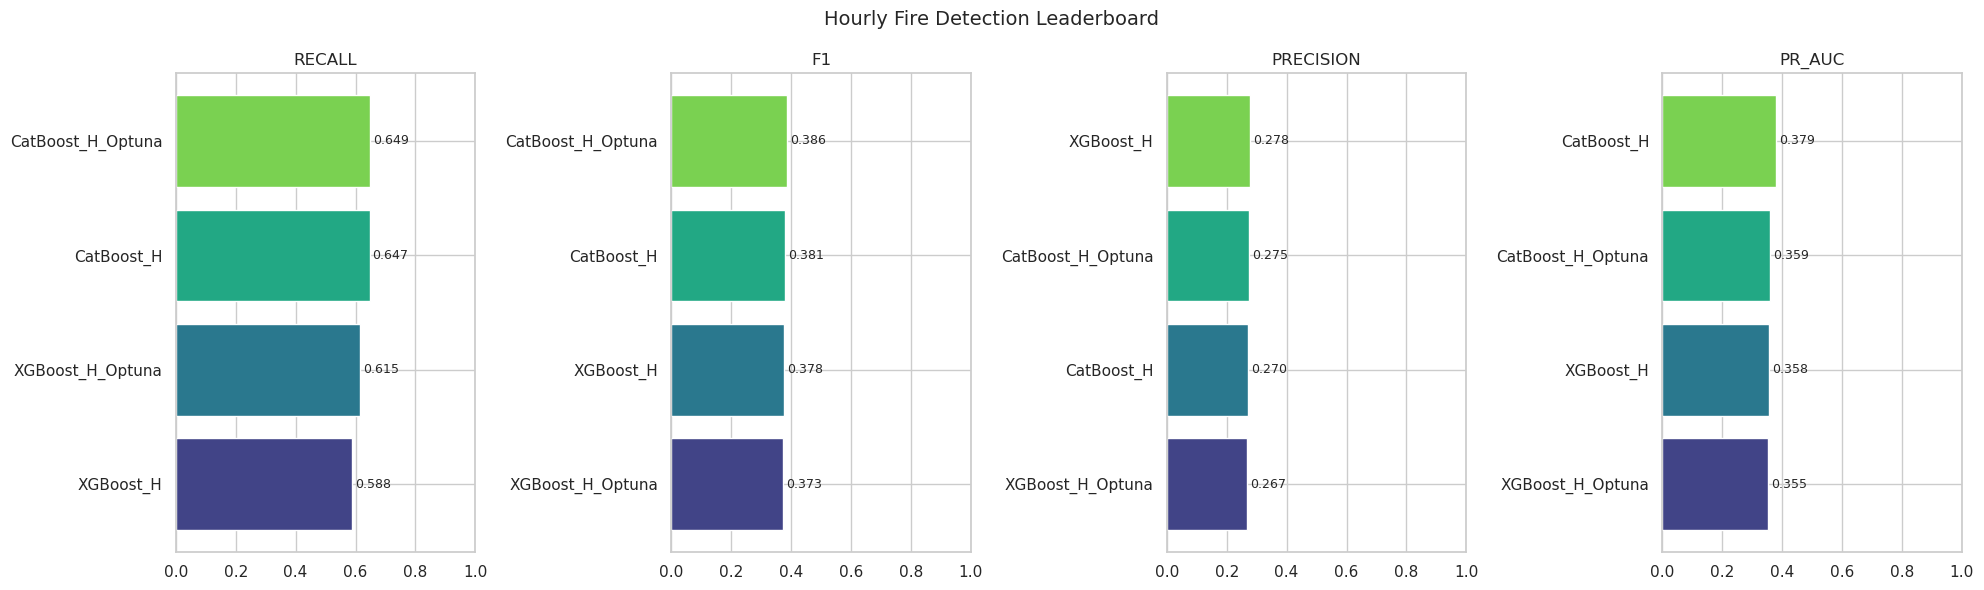


Hourly City-level Recall:
  Baku             fires= 1690  recall=0.835  precision=0.350  f1=0.493
  Barda            fires=  793  recall=0.750  precision=0.414  f1=0.534
  Gabala           fires=   39  recall=0.667  precision=0.059  f1=0.109
  Ganja            fires=  377  recall=0.560  precision=0.225  f1=0.321
  Jalilabad        fires=  481  recall=0.680  precision=0.291  f1=0.408
  Khachmaz         fires=  338  recall=0.675  precision=0.227  f1=0.340
  Lankaran         fires=  247  recall=0.692  precision=0.238  f1=0.354
  Mingachevir      fires=  585  recall=0.858  precision=0.278  f1=0.420
  Nakhchivan       fires=  338  recall=0.183  precision=0.082  f1=0.113


  Quba             fires=  273  recall=0.560  precision=0.184  f1=0.277
  Shabran          fires=    0
  Shaki            fires=  624  recall=0.588  precision=0.308  f1=0.405
  Shamakhi         fires=  156  recall=0.545  precision=0.086  f1=0.149
  Shirvan          fires=  767  recall=0.297  precision=0.412  f1=0.345
  Yevlakh          fires=  559  recall=0.716  precision=0.273  f1=0.396
  Zaqatala         fires=  130  recall=0.292  precision=0.170  f1=0.215

Hourly Overfitting Diagnostic (train-vs-test F1 gap):
  CatBoost_H_Optuna               gap=+0.070
  XGBoost_H_Optuna                gap=+0.069
  XGBoost_H                       gap=+0.052
  CatBoost_H                      gap=+0.026


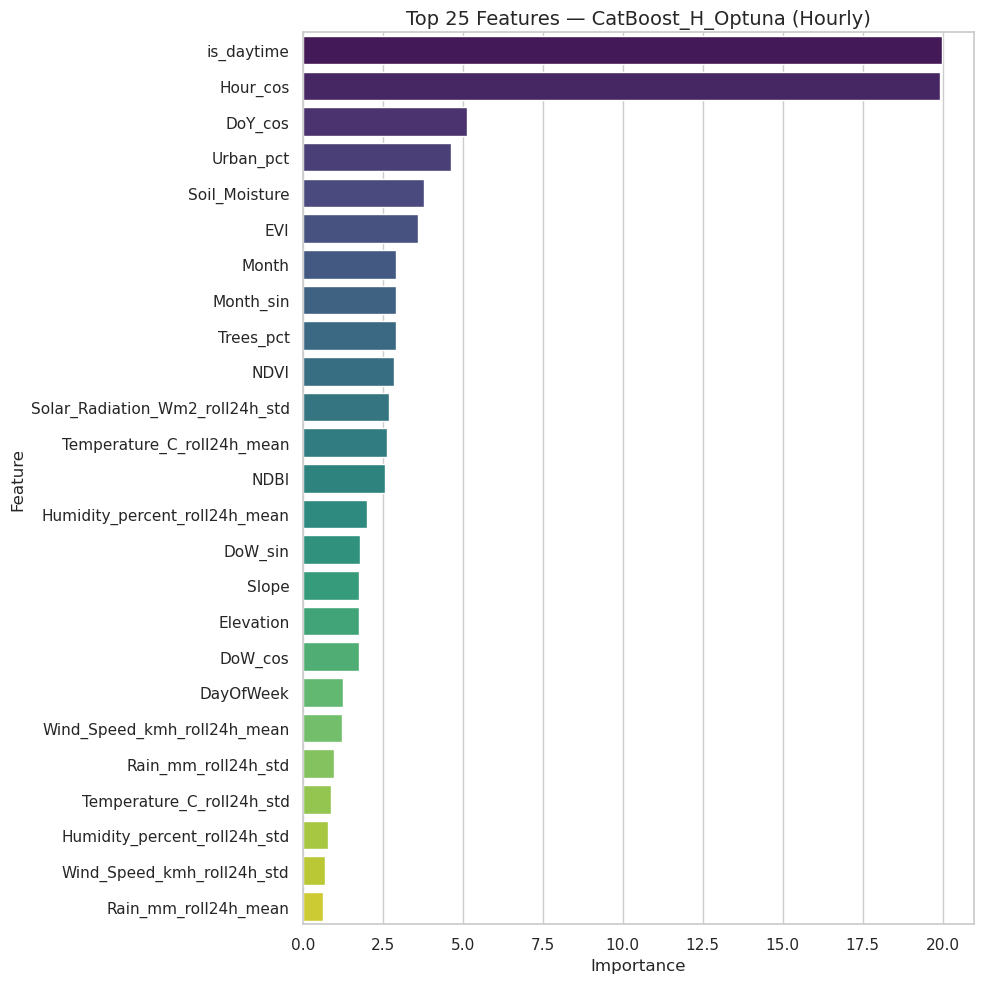

Computing hourly SHAP values (2 000 sample) …


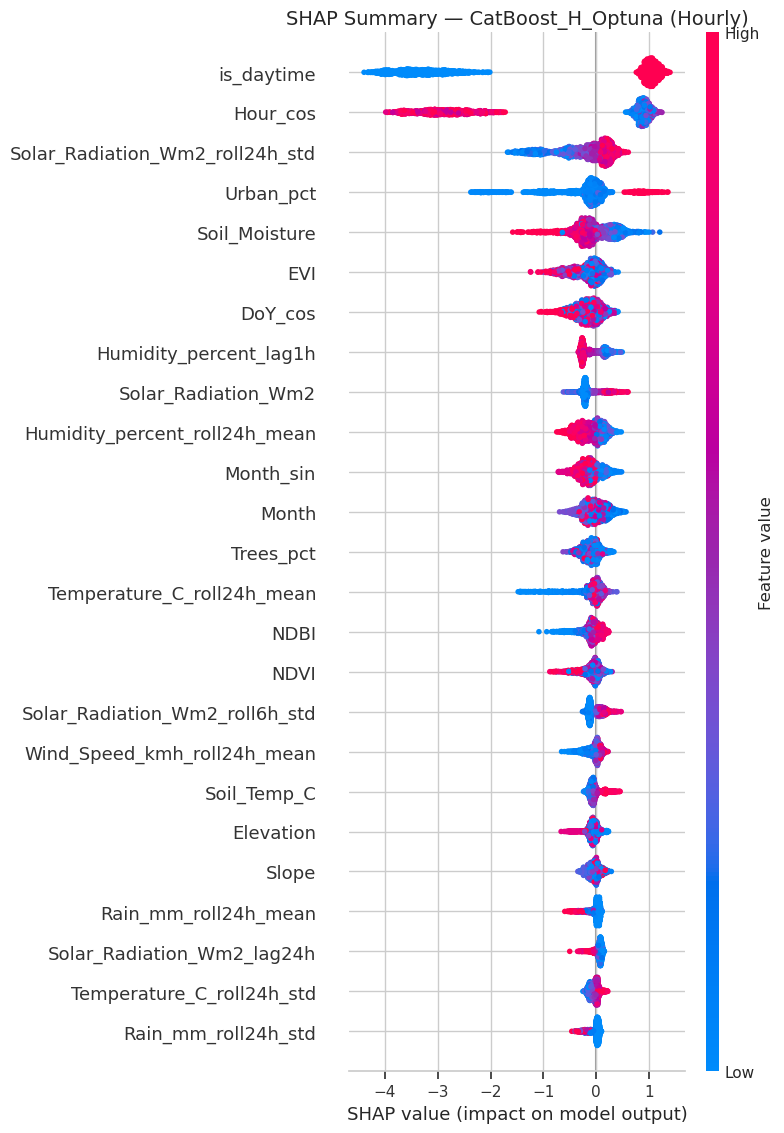

Hourly SHAP complete.


In [12]:
# ─── §B8: Hourly evaluation — plots, SHAP, city-level recall ─────────────

# B8a. Confusion matrices — all hourly models
h_model_names = list(h_results.keys())
fig, axes = plt.subplots(1, len(h_model_names), figsize=(6*len(h_model_names), 5))
if len(h_model_names) == 1: axes = [axes]
fig.suptitle("Hourly Confusion Matrices (daytime-masked labels)", fontsize=14)
for ax, nm in zip(axes, h_model_names):
    r = h_results[nm]
    plot_confusion_matrix(r["y_true"], r["y_pred"], title=nm, ax=ax)
plt.tight_layout()
plt.savefig(FIGURES / "fire_confusion_matrices_hourly.png", dpi=150, bbox_inches="tight")
plt.show()

# B8b. PR curves
fig, ax = plt.subplots(figsize=(10, 8))
h_curves = {nm: r["y_prob"] for nm, r in h_results.items()}
plot_pr_curves(h_curves, hy_test, title="Hourly Precision-Recall Curves", ax=ax)
plt.tight_layout()
plt.savefig(FIGURES / "fire_pr_curves_hourly.png", dpi=150, bbox_inches="tight")
plt.show()

# B8c. Leaderboard chart
fig = plot_leaderboard(h_leaderboard, title="Hourly Fire Detection Leaderboard")
if fig:
    plt.savefig(FIGURES / "fire_leaderboard_chart_hourly.png", dpi=150, bbox_inches="tight")
    plt.show()

# B8d. City-level recall
print("\nHourly City-level Recall:")
h_tmp = h_test[["City", TARGET_COL]].copy()
h_tmp["pred"] = H_FINAL_PRED
h_city_met = []
for city in sorted(h_tmp["City"].unique()):
    cm = h_tmp[h_tmp["City"] == city]
    nf = int(cm[TARGET_COL].sum())
    if nf > 0:
        r = recall_score(cm[TARGET_COL], cm["pred"], zero_division=0)
        p = precision_score(cm[TARGET_COL], cm["pred"], zero_division=0)
        f = f1_score(cm[TARGET_COL], cm["pred"], zero_division=0)
    else:
        r, p, f = np.nan, np.nan, np.nan
    h_city_met.append({"City": city, "n_fires": nf, "recall": r, "precision": p, "f1": f})
    if nf > 0:
        print(f"  {city:15s}  fires={nf:5d}  recall={r:.3f}  precision={p:.3f}  f1={f:.3f}")
    else:
        print(f"  {city:15s}  fires=    0")
pd.DataFrame(h_city_met).to_csv(METRICS / "fire_city_metrics_hourly.csv", index=False)

# B8e. Overfitting diagnostic
print("\nHourly Overfitting Diagnostic (train-vs-test F1 gap):")
for nm, r in sorted(h_results.items(), key=lambda x: x[1].get("overfit_gap", 0), reverse=True):
    g = r.get("overfit_gap", 0)
    flag = " ← WARNING" if g > 0.15 else ""
    print(f"  {nm:30s}  gap={g:+.3f}{flag}")

# B8f. Feature importance
h_raw_model = h_best_model
if hasattr(h_raw_model, "feature_importances_"):
    h_imp = h_raw_model.feature_importances_
elif hasattr(h_raw_model, "coef_"):
    h_imp = np.abs(h_raw_model.coef_).ravel()
else:
    h_imp = np.zeros(len(h_feat_cols))

h_fi = pd.DataFrame({"Feature": h_feat_cols, "Importance": h_imp})
h_fi = h_fi.sort_values("Importance", ascending=False).reset_index(drop=True)
h_fi.to_csv(METRICS / "fire_feature_importance_hourly.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 10))
plot_feature_importance(h_fi["Feature"].values, h_fi["Importance"].values,
                        top_n=25, title=f"Top 25 Features — {H_BEST_NAME} (Hourly)", ax=ax)
plt.tight_layout()
plt.savefig(FIGURES / "fire_feature_importance_hourly.png", dpi=150, bbox_inches="tight")
plt.show()

# B8g. SHAP explainability
try:
    import shap
    print("Computing hourly SHAP values (2 000 sample) …")
    h_idx = np.random.choice(len(hX_test), min(2000, len(hX_test)), replace=False)
    hX_shap = hX_test.iloc[h_idx]
    h_explainer = shap.TreeExplainer(h_raw_model)
    h_sv = h_explainer.shap_values(hX_shap)
    if isinstance(h_sv, list): h_sv = h_sv[1]

    fig, ax = plt.subplots(figsize=(12, 10))
    shap.summary_plot(h_sv, hX_shap, max_display=25, show=False)
    plt.title(f"SHAP Summary — {H_BEST_NAME} (Hourly)", fontsize=14)
    plt.tight_layout()
    plt.savefig(FIGURES / "fire_shap_summary_hourly.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Hourly SHAP complete.")
except ImportError:
    print("shap not installed — pip install shap")
except Exception as e:
    print(f"Hourly SHAP failed: {e}")

In [13]:
# ─── NB04 FINAL SUMMARY ──────────────────────────────────────────────────
print("=" * 60)
print("NB04 COMPLETE — RECALL-FIRST WILDFIRE DETECTION")
print("=" * 60)

print(f"\n  DAILY MODEL:  {BEST_NAME}")
print(f"    Threshold:  {FINAL_THRESH}")
print(f"    Recall:     {m_final['recall']:.4f}")
print(f"    Precision:  {m_final['precision']:.4f}")
print(f"    F1:         {m_final['f1']:.4f}")
print(f"    F2:         {_f2_t:.4f}")
print(f"    PR-AUC:     {m_final.get('pr_auc',0):.4f}")
print(f"    FP:         {m_final['fp']}")
print(f"    FN:         {m_final['fn']}")
print(f"    Models compared: {len(results)}")

print(f"\n  HOURLY MODEL: {H_BEST_NAME}  (daytime-masked labels)")
print(f"    Recall={h_m_final['recall']:.4f}  Prec={h_m_final['precision']:.4f}  "
      f"F1={h_m_final['f1']:.4f}  PR-AUC={h_m_final.get('pr_auc',0):.4f}")
print(f"    Threshold={H_FINAL_THRESH:.2f}  Models compared={len(h_results)}")

print(f"\n  THRESHOLD ANALYSIS:")
print(f"    Selection: {_sel_note}")
if _max_prec_at_rec70 < 0.30:
    print(f"    Limitation: recall≥0.70 → max precision={_max_prec_at_rec70:.4f}")
    print(f"                precision≥0.30 → max recall={_rec_at_prec30:.4f}")
print(f"    Justification: {100*_r_t:.1f}% of fires caught; {_fn_t} missed, {_fp_t} false alarms")

print(f"\n  Strategy: RECALL-FIRST (0.6×Recall + 0.4×F1)")
print(f"  Threshold: tuned via validation sweep (NOT default 0.5)")
print(f"  Min precision floor: {MIN_PRECISION}")
print(f"  Optuna trials: {N_TRIALS} per GBT model")

print(f"\n  Ensemble methods:")
print(f"    SoftVoting_Top3   — average of top-3 probabilities")
print(f"    Stacking_Top3     — LogReg meta-learner on OOF probs")
print(f"    RoleBlend_All     — recall-weighted blend of ALL models")
print(f"    MLP_Neural        — 3-layer neural network for diversity")

print(f"\n  Artifacts in: {MODELS_F}")
print(f"    best_fire_model.joblib          (daily)")
print(f"    best_fire_model_hourly.joblib   (hourly)")
print(f"    model_manifest.json             (daily)")
print(f"    model_manifest_hourly.json      (hourly)")
print(f"    final_threshold.json            (threshold analysis)")
print(f"    threshold_tradeoff.csv          (full sweep)")
print(f"    threshold_tradeoff.png          (visualization)")

print(f"\n→ Next: 05_Risk_Prediction_Dashboard.ipynb")

NB04 COMPLETE — RECALL-FIRST WILDFIRE DETECTION

  DAILY MODEL:  CatBoost_Optuna
    Threshold:  0.44
    Recall:     0.7996
    Precision:  0.2638
    F1:         0.3967
    F2:         0.5686
    PR-AUC:     0.4192
    FP:         1270
    FN:         114
    Models compared: 14

  HOURLY MODEL: CatBoost_H_Optuna  (daytime-masked labels)
    Recall=0.6495  Prec=0.2746  F1=0.3860  PR-AUC=0.3589
    Threshold=0.58  Models compared=4

  THRESHOLD ANALYSIS:
    Selection: recall≥0.70 (precision<0.30 unavoidable), best F2
    Limitation: recall≥0.70 → max precision=0.1899
                precision≥0.30 → max recall=0.4497
    Justification: 80.0% of fires caught; 114 missed, 1270 false alarms

  Strategy: RECALL-FIRST (0.6×Recall + 0.4×F1)
  Threshold: tuned via validation sweep (NOT default 0.5)
  Min precision floor: 0.3
  Optuna trials: 100 per GBT model

  Ensemble methods:
    SoftVoting_Top3   — average of top-3 probabilities
    Stacking_Top3     — LogReg meta-learner on OOF probs
